# 07 - Modèle de prédiction des pertes économiques

## Objectif

L'objectif de ce modèle est de prédire les pertes économiques potentielles causées par un séisme.

Il s'agit d'un problème de **régression**, car la variable cible représente une valeur numérique.

## 1. Import des bibliothèques

Je commence par importer les bibliothèques nécessaires pour manipuler les données, effectuer les calculs, créer les graphiques et entraîner les modèles de régression.

In [8]:
# ============================================================
# MODÈLE 7 — PERTES ÉCONOMIQUES
# Prédiction des pertes économiques
# ============================================================

import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

print("Bibliothèques chargées avec succès.")

Bibliothèques chargées avec succès.


**Interprétation du résultat :**

Le chargement s'est bien passé. Les bibliothèques nécessaires sont maintenant prêtes pour la suite du notebook.

In [10]:
# Charger le dataset

file_path = os.path.join("data", "usgs_earthquakes_2025.csv")

df = pd.read_csv(file_path)

print("Fichier chargé avec succès.")
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

df.head()

Fichier chargé avec succès.
Nombre de lignes : 29062
Nombre de colonnes : 35


,mag,place,time,updated,tz,url,detail,felt,cdi,mmi,alert,status,tsunami,sig,net,code,ids,sources,types,nst,dmin,rms,gap,magType,type,title,longitude,latitude,depth,event_id,date_time,year,month,day,hour
0,4.2,"70 km W of Abra Pampa, Argentina",1751241591065,1757018402040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,271,us,7000q9mu,",us7000q9mu,",",us,",",origin,phase-data,",19.0,1.696,0.70,89.0,mb,earthquake,"M 4.2 - 70 km W of Abra Pampa, Argentina",-66.3753,-22.6251,247.528,us7000q9mu,2025-06-29 23:59:51.065000+00:00,2025,6,29,23
1,2.5,"1 km E of Nikolski, Alaska",1751241495097,1757018405040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,96,us,7000qb5r,",ak0258a2rwky,us7000qb5r,",",ak,us,",",origin,phase-data,",17.0,0.035,0.42,198.0,ml,earthquake,"M 2.5 - 1 km E of Nikolski, Alaska",-168.8412,52.9376,61.149,us7000qb5r,2025-06-29 23:58:15.097000+00:00,2025,6,29,23
2,2.8,"31 km SSE of Nikolski, Alaska",1751241219318,1757018405040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,121,us,7000qb5v,",ak0258a2qvpj,us7000qb5v,",",ak,us,",",origin,phase-data,",10.0,0.316,0.51,231.0,ml,earthquake,"M 2.8 - 31 km SSE of Nikolski, Alaska",-168.6544,52.6804,35.000,us7000qb5v,2025-06-29 23:53:39.318000+00:00,2025,6,29,23
3,3.8,"153 km S of Nikolski, Alaska",1751241150341,1757018402040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,222,us,7000q9mt,",ak0258a2qnbw,us7000q9mt,",",ak,us,",",origin,phase-data,",55.0,1.411,0.42,185.0,mb,earthquake,"M 3.8 - 153 km S of Nikolski, Alaska",-168.5438,51.5761,10.000,us7000q9mt,2025-06-29 23:52:30.341000+00:00,2025,6,29,23
4,4.5,"185 km WSW of Tual, Indonesia",1751240317514,1757018402040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,312,us,7000q9mq,",us7000q9mq,",",us,",",origin,phase-data,",31.0,3.637,0.48,93.0,mb,earthquake,"M 4.5 - 185 km WSW of Tual, Indonesia",131.2977,-6.4544,35.000,us7000q9mq,2025-06-29 23:38:37.514000+00:00,2025,6,29,23


**Interprétation du résultat :**

Le fichier a été chargé correctement. Il contient **29 062 séismes** et **35 variables**. Les premières lignes permettent de vérifier la structure des données avant de commencer l'analyse.

## 3. Exploration des données

Je vérifie maintenant la structure du dataset, les types de variables et les valeurs manquantes avant de préparer les données pour le modèle.

In [13]:
# Informations générales sur le dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29062 entries, 0 to 29061
Data columns (total 35 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   mag        29062 non-null  float64
 1   place      29062 non-null  object 
 2   time       29062 non-null  int64  
 3   updated    29062 non-null  int64  
 4   tz         0 non-null      float64
 5   url        29062 non-null  object 
 6   detail     29062 non-null  object 
 7   felt       3877 non-null   float64
 8   cdi        3877 non-null   float64
 9   mmi        1990 non-null   float64
 10  alert      904 non-null    object 
 11  status     29062 non-null  object 
 12  tsunami    29062 non-null  int64  
 13  sig        29062 non-null  int64  
 14  net        29062 non-null  object 
 15  code       29062 non-null  object 
 16  ids        29062 non-null  object 
 17  sources    29062 non-null  object 
 18  types      29062 non-null  object 
 19  nst        27765 non-null  float64
 20  dmin  

**Interprétation du résultat :**

Le dataset contient **29 062 observations** et **35 variables**.

Certaines variables sont complètes, comme `mag`, `depth`, `sig`, `latitude` et `longitude`.

D'autres variables contiennent beaucoup de valeurs manquantes, notamment `tz`, `alert`, `mmi`, `cdi` et `felt`. Ces variables devront être examinées avant de construire le modèle.

## 4. Vérification des valeurs manquantes

Je vérifie les valeurs manquantes afin d'identifier les variables qui nécessitent un prétraitement.

In [16]:
# Calculer le nombre de valeurs manquantes par variable

df.isnull().sum().sort_values(ascending=False)

tz           29062
alert        28158
mmi          27072
felt         25185
cdi          25185
dmin          1305
gap           1302
nst           1297
time             0
mag              0
place            0
status           0
tsunami          0
sig              0
net              0
code             0
detail           0
updated          0
url              0
types            0
sources          0
ids              0
rms              0
magType          0
type             0
title            0
longitude        0
latitude         0
depth            0
event_id         0
date_time        0
year             0
month            0
day              0
hour             0
dtype: int64

**Interprétation du résultat :**

La variable `tz` est entièrement vide.

Les variables `alert`, `mmi`, `felt` et `cdi` contiennent également beaucoup de valeurs manquantes.

Les variables `dmin`, `gap` et `nst` contiennent quelques valeurs manquantes.

Les principales variables comme `mag`, `depth`, `sig`, `latitude`, `longitude` et `tsunami` sont complètes.

## 5. Statistiques descriptives

Je consulte les statistiques descriptives des principales variables numériques afin de mieux comprendre les données avant le prétraitement.

In [18]:
# Statistiques descriptives des principales variables numériques

df[['mag', 'depth', 'sig', 'latitude', 'longitude', 'tsunami']].describe()

,mag,depth,sig,latitude,longitude,tsunami
count,29062.000000,29062.000000,29062.000000,29062.000000,29062.000000,29062.000000
mean,3.932225,56.666893,251.693104,25.276752,-5.452179,0.004852
std,0.844800,103.944863,110.083046,31.354716,133.979064,0.069486
min,2.500000,-3.420000,96.000000,-73.220400,-179.994400,0.000000
25%,3.100000,10.000000,148.000000,2.070675,-139.941275,0.000000
50%,4.200000,15.490000,271.000000,36.019750,-61.226250,0.000000
75%,4.500000,53.800000,312.000000,51.869925,142.128075,0.000000
max,8.800000,669.556000,2910.000000,87.081500,179.999400,1.000000


**Interprétation du résultat :**

La magnitude moyenne des séismes est d'environ **3,93**, avec un maximum de **8,8**.

La profondeur moyenne est d'environ **56,67 km**, mais certains séismes atteignent plus de **669 km** de profondeur.

La variable `sig`, qui représente l'importance d'un événement selon l'USGS, varie fortement et atteint un maximum de **2910**.

La variable `tsunami` est presque toujours égale à 0, ce qui indique que très peu de séismes du dataset sont associés à un tsunami.

## 6. Distribution de la magnitude

Je visualise la distribution de la magnitude afin de voir comment les séismes sont répartis selon leur intensité.

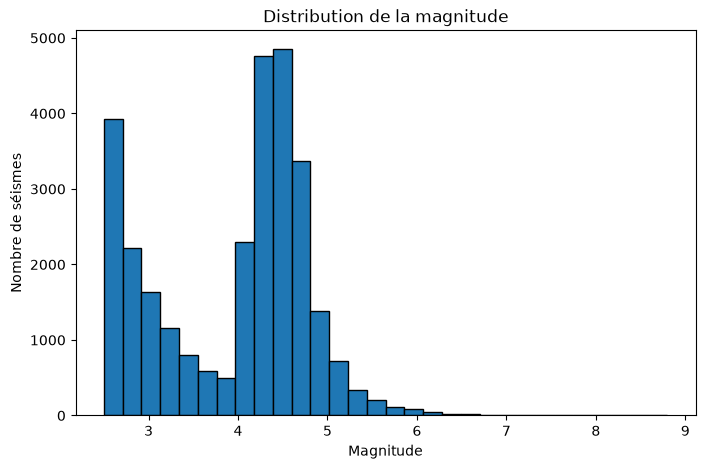

In [19]:
# Visualiser la distribution de la magnitude

plt.figure(figsize=(8, 5))

plt.hist(df['mag'], bins=30, edgecolor='black')

plt.title("Distribution de la magnitude")
plt.xlabel("Magnitude")
plt.ylabel("Nombre de séismes")

plt.show()

**Interprétation du résultat :**

La majorité des séismes ont une magnitude comprise entre **2,5 et 5**.

Les séismes de forte magnitude sont beaucoup plus rares.

Quelques événements dépassent une magnitude de **6**, avec un maximum de **8,8** dans le dataset.

## 7. Distribution de la profondeur

Je visualise la distribution de la profondeur afin d'observer à quelles profondeurs se produisent principalement les séismes du dataset.

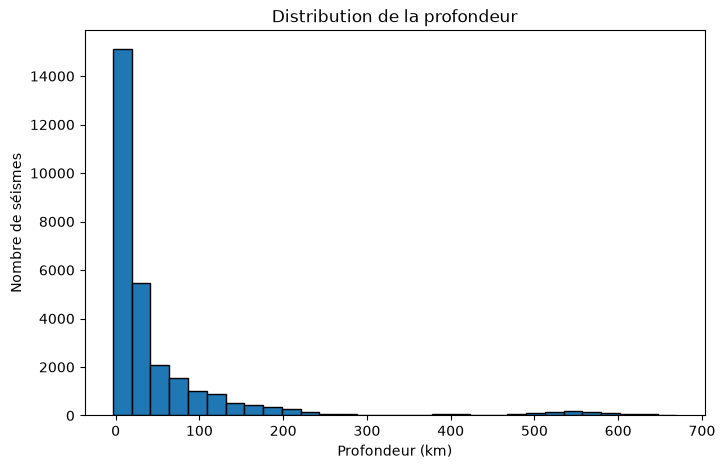

In [22]:
# Visualiser la distribution de la profondeur

plt.figure(figsize=(8, 5))

plt.hist(df['depth'], bins=30, edgecolor='black')

plt.title("Distribution de la profondeur")
plt.xlabel("Profondeur (km)")
plt.ylabel("Nombre de séismes")

plt.show()

**Interprétation du résultat :**

La majorité des séismes se produisent à faible profondeur, principalement sous **100 km**.

Le nombre de séismes diminue fortement lorsque la profondeur augmente.

Quelques séismes très profonds apparaissent entre **500 et 650 km**.

## 8. Relation entre la magnitude et l'importance du séisme

Je vérifie la relation entre la magnitude (`mag`) et l'indice d'importance (`sig`) afin de voir si les séismes plus puissants sont généralement associés à une importance plus élevée.

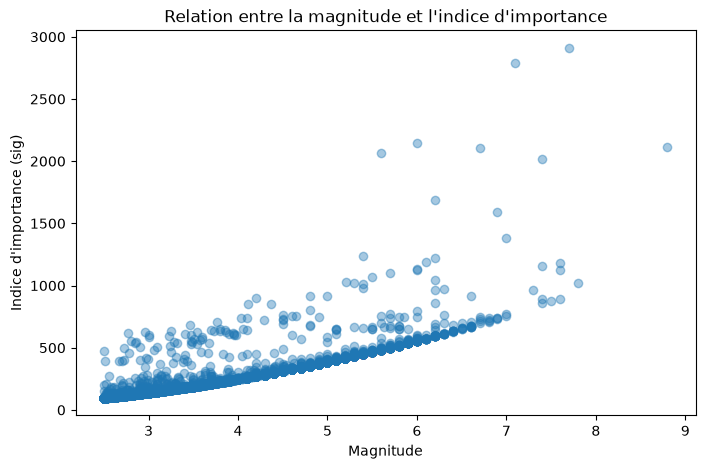

In [24]:
# Relation entre la magnitude et l'indice d'importance

plt.figure(figsize=(8, 5))

plt.scatter(df['mag'], df['sig'], alpha=0.4)

plt.title("Relation entre la magnitude et l'indice d'importance")
plt.xlabel("Magnitude")
plt.ylabel("Indice d'importance (sig)")

plt.show()

**Interprétation du résultat :**

Le graphique montre une relation positive entre la magnitude et l'indice `sig`.

En général, plus la magnitude augmente, plus l'importance du séisme augmente.

Certains événements présentent toutefois un indice `sig` beaucoup plus élevé que les autres, ce qui montre que la magnitude n'est pas le seul facteur associé à l'importance d'un séisme.

## 9. Corrélation entre les variables principales

Je calcule la corrélation entre les principales variables numériques afin d'identifier les relations qui peuvent être utiles pour le modèle.

In [27]:
# Calculer la matrice de corrélation

variables = ['mag', 'depth', 'sig', 'latitude', 'longitude', 'tsunami']

correlation = df[variables].corr()

correlation

,mag,depth,sig,latitude,longitude,tsunami
mag,1.000000,0.138449,0.927889,-0.471871,0.615148,0.123800
depth,0.138449,1.000000,0.101972,-0.298971,-0.020736,-0.011504
sig,0.927889,0.101972,1.000000,-0.411836,0.532706,0.203798
latitude,-0.471871,-0.298971,-0.411836,1.000000,-0.132575,0.026554
longitude,0.615148,-0.020736,0.532706,-0.132575,1.000000,-0.032618
tsunami,0.123800,-0.011504,0.203798,0.026554,-0.032618,1.000000


**Interprétation du résultat :**

La magnitude (`mag`) et l'indice d'importance (`sig`) présentent une très forte corrélation positive de **0,93**.

La magnitude présente également une corrélation positive avec la longitude (**0,62**) dans ce dataset.

La profondeur a des corrélations relativement faibles avec les autres variables.

Ces résultats permettent de mieux comprendre les relations entre les variables avant de construire le modèle de prédiction.

## 10. Définition de la variable cible

Le dataset USGS ne contient pas directement une variable représentant les pertes économiques en dollars.

Avant d'entraîner un modèle de régression, je dois donc définir une variable cible (`Y`) représentant les pertes économiques à partir d'une source de données appropriée, plutôt que d'inventer artificiellement des valeurs de pertes.

In [30]:
# Rechercher une variable pouvant représenter les pertes économiques

keywords = ['loss', 'damage', 'cost', 'economic', 'money']

economic_columns = [
    col for col in df.columns
    if any(word in col.lower() for word in keywords)
]

print("Variables économiques trouvées :", economic_columns)

Variables économiques trouvées : []


**Interprétation du résultat :**

Aucune variable représentant directement les pertes économiques n'est disponible dans le dataset USGS.

Pour construire un modèle supervisé de prédiction des pertes économiques, il est nécessaire d'obtenir ou de construire une variable cible `Y` à partir de données réelles sur les pertes économiques associées aux séismes.

Il ne serait pas approprié d'inventer des montants en dollars à partir de la magnitude, car le modèle apprendrait simplement la formule utilisée pour créer la cible.

## 12. Source de la variable cible

Pour entraîner le modèle, la variable cible `Y` doit représenter une perte économique réelle.

Les données USGS seront donc utilisées pour les caractéristiques du séisme (`X`), tandis qu'une source externe de pertes économiques sera utilisée pour obtenir la cible (`Y`).

Les deux jeux de données pourront ensuite être associés aux événements correspondants.

## 13. Sélection des variables explicatives

Je sélectionne les caractéristiques du séisme qui pourront être utilisées comme variables explicatives (`X`) pour prédire les pertes économiques.

In [33]:
# Sélection des variables explicatives

features = [
    'mag',
    'depth',
    'sig',
    'latitude',
    'longitude',
    'tsunami'
]

X = df[features].copy()

X.head()

,mag,depth,sig,latitude,longitude,tsunami
0,4.2,247.528,271,-22.6251,-66.3753,0
1,2.5,61.149,96,52.9376,-168.8412,0
2,2.8,35.000,121,52.6804,-168.6544,0
3,3.8,10.000,222,51.5761,-168.5438,0
4,4.5,35.000,312,-6.4544,131.2977,0


**Interprétation du résultat :**

Les variables explicatives `X` contiennent **6 caractéristiques** du séisme : la magnitude, la profondeur, l'indice d'importance, la latitude, la longitude et l'indicateur de tsunami.

Ces variables sont complètes et pourront être utilisées comme entrées du modèle de prédiction.

## 14. Conservation de l'identifiant des événements

Je conserve l'identifiant unique `event_id` de chaque séisme.

Cet identifiant permettra d'associer les données USGS aux données réelles de pertes économiques provenant d'une autre source.

In [36]:
# Conserver l'identifiant unique de chaque séisme

event_ids = df['event_id'].copy()

event_ids.head()

0    us7000q9mu
1    us7000qb5r
2    us7000qb5v
3    us7000q9mt
4    us7000q9mq
Name: event_id, dtype: object

**Interprétation du résultat :**

Chaque séisme possède un identifiant unique `event_id`, par exemple `us7000q9mu`.

Cet identifiant sera utilisé pour associer chaque événement USGS à une éventuelle donnée de perte économique, mais il ne sera pas utilisé comme variable d'entrée du modèle.

## 15. Vérification des variables explicatives

Je vérifie les dimensions de `X` afin de confirmer que toutes les observations ont été conservées après la sélection des variables.

In [39]:
# Vérifier les dimensions de X

print("Nombre de lignes :", X.shape[0])
print("Nombre de variables :", X.shape[1])

Nombre de lignes : 29062
Nombre de variables : 6


**Interprétation du résultat :**

La matrice `X` contient **29 062 observations** et **6 variables explicatives**.

Aucune observation n'a été perdue lors de la sélection des variables.

## 16. Vérification des valeurs manquantes dans X

Je vérifie que les variables sélectionnées pour le modèle ne contiennent aucune valeur manquante.

In [42]:
# Vérifier les valeurs manquantes dans X

X.isnull().sum()

mag          0
depth        0
sig          0
latitude     0
longitude    0
tsunami      0
dtype: int64

**Interprétation du résultat :**

Les six variables sélectionnées ne contiennent aucune valeur manquante.

Les données explicatives `X` sont donc complètes et ne nécessitent pas de traitement des valeurs manquantes.

## 17. Préparation de la variable cible Y

La matrice `X` est maintenant prête.

La prochaine étape consiste à obtenir la variable cible `Y`, représentant les pertes économiques réelles associées aux séismes.

Cette variable devra être associée aux événements USGS avant de diviser les données en ensembles d'entraînement et de test.

## 18. Données économiques USGS PAGER

Pour obtenir la variable cible `Y`, j'utilise les données **USGS PAGER**.

PAGER fournit des estimations des pertes économiques associées aux séismes significatifs.

Ces informations permettront de construire une cible économique basée sur des estimations USGS plutôt que sur des valeurs inventées.

## 19. Vérification des données PAGER

Avant de récupérer les pertes économiques pour l'ensemble du dataset, je vérifie la disponibilité des données PAGER pour un événement USGS.

Cette étape permet de comprendre la structure des données économiques avant de les intégrer au dataset.

In [48]:
# Sélectionner le séisme de plus forte magnitude du dataset

event_test = df.loc[df['mag'].idxmax()]

print("Event ID :", event_test['event_id'])
print("Magnitude :", event_test['mag'])
print("Lieu :", event_test['place'])
print("Date :", event_test['date_time'])

Event ID : us6000qw60
Magnitude : 8.8
Lieu : 2025 Kamchatka Peninsula, Russia Earthquake
Date : 2025-07-29 23:24:52.483000+00:00


**Interprétation du résultat :**

Le séisme sélectionné possède une magnitude de **8,8** et s'est produit dans la péninsule du Kamchatka en Russie.

Comme il s'agit du séisme de plus forte magnitude du dataset, cet événement constitue un bon candidat pour vérifier la disponibilité des estimations de pertes économiques PAGER.

In [50]:
# Récupérer les détails USGS de l'événement test

import requests

event_id = "us6000qw60"

url = f"https://earthquake.usgs.gov/fdsnws/event/1/query?eventid={event_id}&format=geojson"

response = requests.get(url)

print("Code HTTP :", response.status_code)

event_data = response.json()

print("Données récupérées avec succès.")

Code HTTP : 200
Données récupérées avec succès.


**Interprétation du résultat :**

Le code HTTP **200** confirme que la requête vers le service USGS a réussi.

Les informations détaillées du séisme sont maintenant disponibles dans `event_data`. La prochaine étape consiste à vérifier si cet événement contient un produit **PAGER** avec des informations sur les pertes économiques.

In [52]:
# Afficher les produits disponibles pour cet événement

products = event_data.get("properties", {}).get("products", {})

print("Produits disponibles :")
print(list(products.keys()))

Produits disponibles :
['dyfi', 'earthquake-name', 'event-sequence', 'finite-fault', 'general-link', 'general-text', 'ground-failure', 'impact-link', 'impact-text', 'internal-moment-tensor', 'internal-origin', 'losspager', 'moment-tensor', 'oaf', 'origin', 'phase-data', 'shakemap']


**Interprétation du résultat :**

L'événement possède un produit `losspager`.

Ce produit contient les estimations PAGER liées aux conséquences du séisme, notamment les estimations de pertes économiques.

Nous pouvons donc utiliser `losspager` pour rechercher la variable cible `Y`.

In [54]:
# Récupérer le produit LossPAGER

losspager = products['losspager'][0]

# Afficher les fichiers disponibles dans LossPAGER

contents = losspager.get('contents', {})

print("Fichiers disponibles dans LossPAGER :")

for filename in contents.keys():
    print(filename)

Fichiers disponibles dans LossPAGER :
json/cities.json
onepager.pdf
alertecon.png
json/comments.json
exposure.png
alertfatal_small.png
json/alerts.json
json/exposures.json
json/historical_earthquakes.json
alertecon.pdf
grid.xml
onepager.aux
contents.xml
exposure.pdf
json/losses.json
alertfatal.pdf
alertfatal_smaller.png
json/event.json
onepager.tex
pager.xml
alertecon_small.png
alertecon_smaller.png
alertfatal.png


**Interprétation du résultat :**

Le produit `losspager` contient plusieurs fichiers.

Le fichier `json/losses.json` est particulièrement important pour notre modèle, car il contient les informations relatives aux estimations de pertes.

Je vais maintenant examiner son contenu afin d'identifier la valeur qui pourra servir de variable cible `Y`.

In [55]:
# Récupérer l'URL du fichier losses.json

losses_url = contents['json/losses.json']['url']

# Télécharger les données de pertes
losses_response = requests.get(losses_url)

print("Code HTTP :", losses_response.status_code)

losses_data = losses_response.json()

print("Données de pertes récupérées avec succès.")

Code HTTP : 200
Données de pertes récupérées avec succès.


**Interprétation du résultat :**

Le code HTTP **200** confirme que le fichier `losses.json` a été téléchargé correctement.

Les données PAGER relatives aux pertes sont maintenant disponibles dans la variable `losses_data`.

La prochaine étape consiste à examiner leur structure afin d'identifier précisément les estimations de pertes économiques.

In [56]:
# Examiner la structure des données de pertes

print("Clés disponibles dans losses.json :")

print(losses_data.keys())

Clés disponibles dans losses.json :
dict_keys(['empirical_fatality', 'empirical_economic', 'semi_empirical_fatalities'])


**Interprétation du résultat :**

Le fichier `losses.json` contient trois catégories de résultats.

La section `empirical_economic` contient les estimations des pertes économiques.

Cette section sera examinée pour déterminer la variable cible `Y` de notre modèle de régression.

In [58]:
# Examiner les données de pertes économiques

economic_data = losses_data['empirical_economic']

print("Type :", type(economic_data))

economic_data

Type : <class 'dict'>


{'total_dollars': 10238972670,
 'country_dollars': [{'country_code': 'RU',
   'rates': [2.0991953314921798e-91,
    2.5310497412664658e-42,
    1.7017430886602766e-22,
    2.196519097843858e-12,
    8.754773553956376e-07,
    0.0012280277383668343,
    0.06083405411828719,
    0.39550427673667554,
    0.8068964192106685,
    0.9698567834013938],
   'us_dollars': 10238972670}]}

**Interprétation du résultat :**

La section `empirical_economic` contient une variable `total_dollars`.

Pour le séisme testé, la perte économique estimée par PAGER est de **10 238 972 670 $**, soit environ **10,24 milliards de dollars**.

Cette variable peut servir de variable cible `Y` pour le modèle de régression des pertes économiques.

Les données `country_dollars` fournissent également une répartition des pertes estimées par pays.

In [59]:
# Extraire la perte économique totale estimée

economic_loss = economic_data['total_dollars']

print("Perte économique estimée :", economic_loss, "$")
print("Perte économique estimée en milliards :", round(economic_loss / 1_000_000_000, 2), "milliards $")

Perte économique estimée : 10238972670 $
Perte économique estimée en milliards : 10.24 milliards $


**Interprétation du résultat :**

La perte économique estimée pour cet événement est de **10 238 972 670 $**, soit environ **10,24 milliards de dollars**.

L'extraction de `total_dollars` fonctionne correctement. Cette valeur pourra donc être utilisée comme variable cible `Y`.

La prochaine étape sera d'automatiser cette extraction pour les événements du dataset qui possèdent des données `losspager`.

## 28. Automatisation de la récupération des pertes économiques

Je crée une fonction qui utilise l'identifiant `event_id` d'un séisme pour rechercher automatiquement les données `losspager` et récupérer la perte économique estimée par PAGER.

Si aucune estimation économique n'est disponible pour un événement, la fonction retournera une valeur manquante.

In [60]:
# Fonction pour récupérer la perte économique PAGER

def get_economic_loss(event_id):
    try:
        # Requête vers les détails de l'événement USGS
        url = f"https://earthquake.usgs.gov/fdsnws/event/1/query?eventid={event_id}&format=geojson"
        response = requests.get(url, timeout=15)

        if response.status_code != 200:
            return np.nan

        event_data = response.json()

        # Vérifier si le produit losspager existe
        products = event_data.get("properties", {}).get("products", {})

        if "losspager" not in products:
            return np.nan

        # Récupérer le produit LossPAGER
        losspager = products["losspager"][0]
        contents = losspager.get("contents", {})

        if "json/losses.json" not in contents:
            return np.nan

        # Télécharger losses.json
        losses_url = contents["json/losses.json"]["url"]
        losses_response = requests.get(losses_url, timeout=15)

        if losses_response.status_code != 200:
            return np.nan

        losses_data = losses_response.json()

        # Extraire la perte économique
        economic_data = losses_data.get("empirical_economic", {})

        return economic_data.get("total_dollars", np.nan)

    except Exception:
        return np.nan

In [61]:
# Tester la fonction sur l'événement déjà utilisé

test_loss = get_economic_loss("us6000qw60")

print("Perte économique récupérée :", test_loss, "$")

Perte économique récupérée : 10238972670 $


**Interprétation du résultat :**

La fonction retourne correctement une perte économique estimée de **10 238 972 670 $** pour l'événement testé.

Le résultat est identique à celui obtenu lors de l'extraction manuelle.

La fonction peut donc être utilisée pour récupérer automatiquement les pertes économiques PAGER des autres séismes.

## 30. Sélection des séismes significatifs

Les données PAGER ne sont pas disponibles pour tous les séismes.

Afin d'éviter des milliers de requêtes inutiles, je sélectionne d'abord les événements ayant une magnitude supérieure ou égale à **5,0**.

Ces événements seront utilisés pour rechercher les estimations de pertes économiques PAGER.

In [63]:
# Sélectionner les séismes de magnitude >= 5.0

df_significant = df[df['mag'] >= 5.0].copy()

print("Nombre total de séismes :", len(df))
print("Nombre de séismes de magnitude >= 5.0 :", len(df_significant))

Nombre total de séismes : 29062
Nombre de séismes de magnitude >= 5.0 : 2122


**Interprétation du résultat :**

Le dataset contient **29 062 séismes** au total.

Parmi eux, **2 122 séismes** ont une magnitude supérieure ou égale à **5,0**.

Cette sélection réduit fortement le nombre de requêtes à effectuer et permet de concentrer la recherche PAGER sur les événements les plus significatifs.

## 31. Test de récupération sur un échantillon

Avant d'appliquer la fonction à tous les séismes sélectionnés, je la teste sur un petit échantillon de **10 événements**.

Cette étape permet de vérifier que la récupération automatique fonctionne correctement.

In [65]:
# Tester la récupération sur 10 séismes

sample_events = df_significant.head(10).copy()

sample_events['economic_loss'] = sample_events['event_id'].apply(get_economic_loss)

sample_events[['event_id', 'mag', 'place', 'economic_loss']]

,event_id,mag,place,economic_loss
47,us7000q9hh,5.2,"103 km N of Tatsugō, Japan",NaN
50,us7000q9hc,5.3,"162 km SSW of Lorengau, Papua New Guinea",NaN
54,us7000q9h4,5.1,south of Panama,NaN
72,us7000q9fs,5.4,"98 km NNW of Tatsugō, Japan",0.0
80,us7000q9f3,5.2,"56 km NNE of Barkhan, Pakistan",68378.0
86,us7000q9e7,5.0,"24 km SSW of Puerto San José, Guatemala",NaN
92,us7000q9dv,5.2,South Sandwich Islands region,NaN
108,us7000q9d1,5.3,"136 km NNW of Tobelo, Indonesia",NaN
117,us7000q9cb,5.1,"288 km NW of Chokurdakh, Russia",NaN
123,us7000q9b5,6.6,Scotia Sea,0.0


**Interprétation du résultat :**

Le test montre que les données PAGER ne sont pas disponibles pour tous les séismes de magnitude supérieure ou égale à **5,0**.

Une valeur `NaN` indique qu'aucune estimation économique exploitable n'a été trouvée pour l'événement.

Une valeur `0.0` indique qu'une estimation PAGER existe, mais que la perte économique estimée est nulle.

Certaines observations possèdent une perte économique positive, par exemple **68 378 $**.

Il est donc important de conserver la différence entre une valeur manquante (`NaN`) et une perte estimée à zéro.

In [66]:
# Compter les données économiques disponibles

available = sample_events['economic_loss'].notna().sum()
missing = sample_events['economic_loss'].isna().sum()

print("Pertes économiques disponibles :", available)
print("Pertes économiques manquantes :", missing)

Pertes économiques disponibles : 3
Pertes économiques manquantes : 7


**Interprétation du résultat :**

Sur les **10 séismes** testés, **3 événements** possèdent une estimation de perte économique PAGER et **7 événements** n'en possèdent pas.

Cela confirme que les données économiques ne sont disponibles que pour une partie des événements.

Pour entraîner le modèle, seules les observations disposant d'une valeur économique réelle seront conservées.

## 33. Récupération des pertes économiques PAGER

Je récupère maintenant les estimations de pertes économiques pour les séismes significatifs sélectionnés.

Les résultats seront sauvegardés afin d'éviter de refaire toutes les requêtes lors d'une prochaine exécution du notebook.

In [69]:
# Récupérer les pertes économiques et sauvegarder progressivement

output_file = "data/pager_economic_losses_2025.csv"

df_losses = df_significant[
    ['event_id', 'mag', 'depth', 'sig', 'latitude', 'longitude', 'tsunami', 'place']
].copy()

df_losses['economic_loss'] = np.nan

for i, index in enumerate(df_losses.index):

    event_id = df_losses.loc[index, 'event_id']

    df_losses.loc[index, 'economic_loss'] = get_economic_loss(event_id)

    # Sauvegarde tous les 100 événements
    if (i + 1) % 100 == 0:
        df_losses.to_csv(output_file, index=False)
        print(f"{i + 1} événements traités")

# Sauvegarde finale
df_losses.to_csv(output_file, index=False)

print("Terminé.")
print("Fichier sauvegardé :", output_file)

100 événements traités
200 événements traités
300 événements traités
400 événements traités
500 événements traités
600 événements traités
700 événements traités
800 événements traités
900 événements traités
1000 événements traités
1100 événements traités
1200 événements traités
1300 événements traités
1400 événements traités
1500 événements traités
1600 événements traités
1700 événements traités
1800 événements traités
1900 événements traités
2000 événements traités
2100 événements traités
Terminé.
Fichier sauvegardé : data/pager_economic_losses_2025.csv


In [70]:
# Vérifier les données économiques récupérées

print("Nombre d'événements analysés :", len(df_losses))
print("Pertes disponibles :", df_losses['economic_loss'].notna().sum())
print("Pertes manquantes :", df_losses['economic_loss'].isna().sum())

Nombre d'événements analysés : 2122
Pertes disponibles : 734
Pertes manquantes : 1388


**Interprétation du résultat :**

Parmi les **2 122 séismes significatifs** analysés, **734 événements** possèdent une estimation de perte économique PAGER.

Pour **1 388 événements**, aucune estimation économique n'est disponible.

Le modèle de régression sera donc construit à partir des **734 observations** pour lesquelles la variable cible `economic_loss` est disponible.

## 35. Création du dataset final

Je conserve uniquement les séismes pour lesquels une estimation de perte économique PAGER est disponible.

Ce nouveau dataset sera utilisé pour entraîner et évaluer le modèle de régression.

In [71]:
# Conserver uniquement les événements avec une perte économique disponible

df_model = df_losses.dropna(subset=['economic_loss']).copy()

print("Nombre d'observations pour le modèle :", len(df_model))

df_model.head()

Nombre d'observations pour le modèle : 734


,event_id,mag,depth,sig,latitude,longitude,tsunami,place,economic_loss
72,us7000q9fs,5.4,10.00,449,29.3062,129.3422,0,"98 km NNW of Tatsugō, Japan",0.0
80,us7000q9f3,5.2,10.00,419,30.3495,69.7968,0,"56 km NNE of Barkhan, Pakistan",68378.0
123,us7000q9b5,6.6,10.00,670,-60.9793,-38.9672,1,Scotia Sea,0.0
137,us7000q99p,5.5,229.00,465,-19.8818,-176.0335,0,"161 km NNW of Houma, Tonga",0.0
155,us7000q97d,6.0,99.77,594,5.2888,126.0425,0,"65 km E of Sarangani, Philippines",0.0


**Interprétation du résultat :**

Le dataset final contient uniquement les séismes pour lesquels une estimation économique PAGER est disponible.

Les pertes économiques égales à **0 $** sont conservées, car elles représentent une estimation réelle de PAGER et non une valeur manquante.

La colonne `economic_loss` constitue maintenant la variable cible `Y` du modèle de régression.

## 36. Définition de X et Y

Je définis les variables explicatives `X` et la variable cible `Y`.

`X` contient les caractéristiques du séisme utilisées pour faire la prédiction.

`Y` correspond à la perte économique estimée par PAGER (`economic_loss`).

In [72]:
# Définir les variables explicatives X et la cible Y

features = [
    'mag',
    'depth',
    'sig',
    'latitude',
    'longitude',
    'tsunami'
]

X = df_model[features].copy()
y = df_model['economic_loss'].copy()

print("Dimensions de X :", X.shape)
print("Dimensions de Y :", y.shape)

Dimensions de X : (734, 6)
Dimensions de Y : (734,)


**Interprétation du résultat :**

`X` contient **734 observations** et **6 variables explicatives**.

`Y` contient **734 valeurs de pertes économiques**.

Les dimensions de `X` et `Y` correspondent. Les données sont donc prêtes pour la préparation du modèle de régression.

## 37. Distribution de la variable cible

Je vérifie la distribution des pertes économiques afin de comprendre l'échelle et la dispersion de la variable cible `Y`.

In [74]:
# Statistiques de la variable cible Y

print(y.describe())

print("\nPerte économique maximale :", y.max(), "$")
print("Nombre de pertes égales à 0 :", (y == 0).sum())

count    7.340000e+02
mean     9.758211e+07
std      1.996151e+09
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      5.299175e+10
Name: economic_loss, dtype: float64

Perte économique maximale : 52991751137.0 $
Nombre de pertes égales à 0 : 625


**Interprétation du résultat :**

La variable cible `economic_loss` est très déséquilibrée.

Sur **734 événements**, **625** ont une perte économique estimée à **0 $**, tandis que seulement **109 événements** présentent une perte positive.

La perte maximale atteint environ **52,99 milliards de dollars**.

La moyenne est beaucoup plus élevée que la médiane, qui est de **0 $**. Cela montre que quelques pertes économiques très importantes influencent fortement la distribution.

Cette forte asymétrie devra être prise en compte lors de l'entraînement et de l'évaluation des modèles de régression.

## 38. Visualisation des pertes économiques

Je visualise la distribution des pertes économiques afin d'observer l'écart entre les événements sans perte et les événements ayant des pertes économiques importantes.

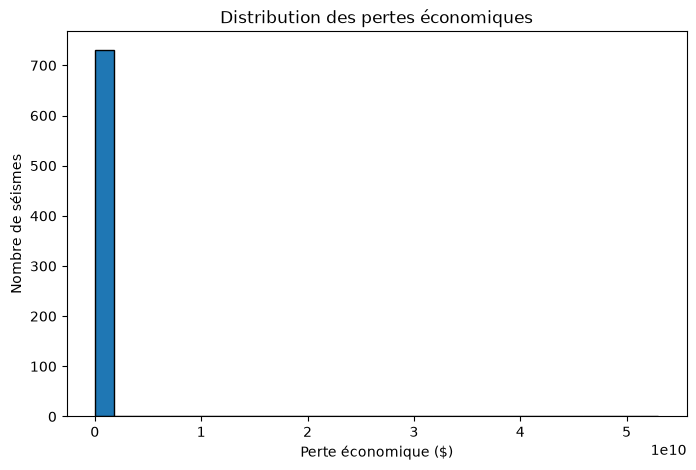

In [76]:
# Visualiser la distribution des pertes économiques

plt.figure(figsize=(8, 5))

plt.hist(y, bins=30, edgecolor='black')

plt.title("Distribution des pertes économiques")
plt.xlabel("Perte économique ($)")
plt.ylabel("Nombre de séismes")

plt.show()

**Interprétation du résultat :**

La distribution des pertes économiques est fortement asymétrique.

La majorité des séismes ont une perte économique nulle ou faible, tandis que quelques événements présentent des pertes extrêmement élevées.

Ces valeurs élevées étirent l'échelle du graphique et rendent les petites pertes difficiles à distinguer.

Une transformation logarithmique sera utile pour mieux représenter la variable cible et faciliter l'apprentissage des modèles.

## 39. Transformation logarithmique de la variable cible

Les pertes économiques présentent une très forte asymétrie.

J'applique une transformation logarithmique avec `log1p`, qui permet également de conserver les pertes égales à zéro.

Cette transformation réduit l'influence des valeurs extrêmement élevées et facilite l'apprentissage du modèle.

In [78]:
# Transformation logarithmique de la variable cible

y_log = np.log1p(y)

print("Y original :")
print(y.describe())

print("\nY après transformation logarithmique :")
print(y_log.describe())

Y original :
count    7.340000e+02
mean     9.758211e+07
std      1.996151e+09
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      5.299175e+10
Name: economic_loss, dtype: float64

Y après transformation logarithmique :
count    734.000000
mean       1.504756
std        4.375432
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max       24.693402
Name: economic_loss, dtype: float64


**Interprétation du résultat :**

Avant la transformation, les pertes économiques varient de **0 $ à environ 53 milliards de dollars**, ce qui crée une très forte dispersion.

Après la transformation logarithmique, les valeurs sont comprises entre **0 et 24,69**.

La transformation réduit donc l'effet des pertes extrêmement élevées tout en conservant les événements dont la perte est égale à zéro.

La variable `y_log` sera utilisée pour entraîner les modèles de régression.

## 40. Séparation des données d'entraînement et de test

Je divise les données en deux ensembles.

**80 %** des données seront utilisées pour entraîner les modèles.

**20 %** seront conservées pour tester les modèles sur des données qu'ils n'ont pas utilisées pendant l'entraînement.

In [80]:
# Séparer les données en entraînement et test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_log,
    test_size=0.20,
    random_state=42
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (587, 6)
X_test  : (147, 6)
y_train : (587,)
y_test  : (147,)


**Interprétation du résultat :**

L'ensemble d'entraînement contient **587 observations**, soit environ **80 %** des données.

L'ensemble de test contient **147 observations**, soit environ **20 %** des données.

Le modèle sera entraîné avec `X_train` et `y_train`, puis évalué avec `X_test` et `y_test`.

## 41. Modèle 1 — Régression linéaire

Je commence avec une régression linéaire.

Ce modèle servira de modèle de référence afin de comparer ses performances avec celles des autres algorithmes de régression.

In [83]:
# Modèle 1 : Régression linéaire

from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

# Entraînement du modèle
linear_model.fit(X_train, y_train)

# Prédictions
y_pred_linear = linear_model.predict(X_test)

print("Modèle de régression linéaire entraîné avec succès.")

Modèle de régression linéaire entraîné avec succès.


**Interprétation du résultat :**

Le modèle de régression linéaire a été entraîné avec succès sur les **587 observations** de l'ensemble d'entraînement.

Il a ensuite généré des prédictions pour les **147 observations** de l'ensemble de test.

La prochaine étape consiste à mesurer ses performances à l'aide des métriques de régression.

## 42. Évaluation de la régression linéaire

J'évalue les performances du modèle de régression linéaire à l'aide de trois métriques : **MAE**, **RMSE** et **R²**.

Ces métriques permettent de mesurer l'erreur des prédictions et la capacité du modèle à expliquer les variations de la variable cible.

In [84]:
# Évaluer le modèle de régression linéaire

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("MAE  :", round(mae_linear, 4))
print("RMSE :", round(rmse_linear, 4))
print("R²   :", round(r2_linear, 4))

MAE  : 1.6604
RMSE : 3.0105
R²   : 0.5117


**Interprétation du résultat :**

La régression linéaire obtient un **R² de 0,5117**.

Cela signifie que le modèle explique environ **51 % de la variation** de la variable cible transformée.

La **MAE est de 1,6604** et la **RMSE de 3,0105** sur l'échelle logarithmique.

Ce premier modèle fournit une référence. Les prochains algorithmes permettront de vérifier si un modèle non linéaire peut obtenir de meilleures performances.

## 43. Modèle 2 — Random Forest

Je teste maintenant l'algorithme **Random Forest Regressor**.

Random Forest combine plusieurs arbres de décision et peut détecter des relations non linéaires entre les caractéristiques des séismes et les pertes économiques.

Les performances de ce modèle seront comparées à celles de la régression linéaire.

In [85]:
# Modèle 2 : Random Forest

from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Entraînement du modèle
random_forest_model.fit(X_train, y_train)

# Prédictions
y_pred_rf = random_forest_model.predict(X_test)

print("Modèle Random Forest entraîné avec succès.")

Modèle Random Forest entraîné avec succès.


**Interprétation du résultat :**

Le modèle **Random Forest** a été entraîné avec succès sur les données d'entraînement.

Il a ensuite généré des prédictions pour les observations de l'ensemble de test.

La prochaine étape consiste à calculer les mêmes métriques **MAE, RMSE et R²** afin de comparer ses performances avec celles de la régression linéaire.

## 44. Évaluation du modèle Random Forest

J'évalue maintenant le modèle Random Forest avec les mêmes métriques que la régression linéaire : **MAE**, **RMSE** et **R²**.

L'utilisation des mêmes métriques permettra de comparer directement les deux modèles.

In [86]:
# Évaluer le modèle Random Forest

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE  :", round(mae_rf, 4))
print("RMSE :", round(rmse_rf, 4))
print("R²   :", round(r2_rf, 4))

MAE  : 1.004
RMSE : 2.4327
R²   : 0.6812


**Interprétation du résultat :**

Le modèle **Random Forest** obtient un **R² de 0,6812**, ce qui signifie qu'il explique environ **68 % de la variation** de la variable cible transformée.

La **MAE est de 1,0040** et la **RMSE de 2,4327** sur l'échelle logarithmique.

Ces résultats sont meilleurs que ceux de la régression linéaire, qui avait obtenu un **R² de 0,5117**.

Random Forest est donc, pour le moment, le modèle le plus performant.

## 45. Modèle 3 — Gradient Boosting

Je teste maintenant l'algorithme **Gradient Boosting Regressor**.

Gradient Boosting construit plusieurs arbres de décision successivement. Chaque nouvel arbre cherche à corriger les erreurs produites par les arbres précédents.

Les résultats seront comparés à ceux de la régression linéaire et de Random Forest.

In [87]:
# Modèle 3 : Gradient Boosting

from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=200,
    random_state=42
)

# Entraînement du modèle
gradient_boosting_model.fit(X_train, y_train)

# Prédictions
y_pred_gb = gradient_boosting_model.predict(X_test)

print("Modèle Gradient Boosting entraîné avec succès.")

Modèle Gradient Boosting entraîné avec succès.


**Interprétation du résultat :**

Le modèle **Gradient Boosting** a été entraîné avec succès sur les données d'entraînement.

Il a ensuite généré des prédictions pour les **147 observations** de l'ensemble de test.

La prochaine étape consiste à calculer **MAE, RMSE et R²** afin de comparer ses performances aux deux modèles précédents.

## 46. Évaluation du modèle Gradient Boosting

J'évalue le modèle Gradient Boosting avec les mêmes métriques utilisées pour les modèles précédents : **MAE**, **RMSE** et **R²**.

Cette évaluation permettra de déterminer lequel des trois algorithmes offre les meilleures performances.

In [88]:
# Évaluer le modèle Gradient Boosting

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("MAE  :", round(mae_gb, 4))
print("RMSE :", round(rmse_gb, 4))
print("R²   :", round(r2_gb, 4))

MAE  : 1.0387
RMSE : 2.2755
R²   : 0.721


**Interprétation du résultat :**

Le modèle **Gradient Boosting** obtient un **R² de 0,7210**, ce qui signifie qu'il explique environ **72 % de la variation** de la variable cible transformée.

La **MAE est de 1,0387** et la **RMSE de 2,2755** sur l'échelle logarithmique.

Gradient Boosting obtient le meilleur **R²** et la plus faible **RMSE** parmi les trois modèles testés.

Random Forest conserve toutefois une MAE légèrement plus faible (**1,0040** contre **1,0387**).

Les trois modèles seront maintenant comparés dans un même tableau.

## 47. Comparaison des modèles

Je compare les performances des trois algorithmes de régression à l'aide des métriques **MAE**, **RMSE** et **R²**.

Cette comparaison permettra de sélectionner le modèle le plus performant pour la prédiction des pertes économiques.

In [89]:
# Comparer les performances des trois modèles

results = pd.DataFrame({
    'Modèle': [
        'Régression linéaire',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MAE': [
        mae_linear,
        mae_rf,
        mae_gb
    ],
    'RMSE': [
        rmse_linear,
        rmse_rf,
        rmse_gb
    ],
    'R²': [
        r2_linear,
        r2_rf,
        r2_gb
    ]
})

results = results.round(4)

results

,Modèle,MAE,RMSE,R²
0,Régression linéaire,1.6604,3.0105,0.5117
1,Random Forest,1.0040,2.4327,0.6812
2,Gradient Boosting,1.0387,2.2755,0.7210


**Interprétation du résultat :**

La **régression linéaire** obtient les performances les plus faibles avec un **R² de 0,5117**.

Le modèle **Random Forest** améliore les résultats avec un **R² de 0,6812** et obtient la plus faible **MAE (1,0040)**.

Le modèle **Gradient Boosting** obtient le meilleur **R² (0,7210)** et la plus faible **RMSE (2,2755)**.

Gradient Boosting explique donc environ **72 % de la variation de la variable cible transformée** et sera retenu comme meilleur modèle parmi les trois algorithmes testés.

## 48. Importance des variables

Je vérifie l'importance des variables utilisées par le modèle Gradient Boosting.

Cette analyse permet d'identifier les caractéristiques du séisme qui influencent le plus les prédictions du modèle.

In [ ]:
# Importance des variables du modèle Gradient Boosting

feature_importance = pd.DataFrame({
    'Variable': X.columns,
    'Importance': gradient_boosting_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

**Interprétation du résultat :**

La variable `sig` est la plus importante pour le modèle Gradient Boosting avec une importance d'environ **68,8 %**.

La magnitude (`mag`) arrive ensuite avec environ **12,1 %**, suivie de la longitude avec **10,4 %** et de la latitude avec **5,4 %**.

La profondeur contribue moins aux prédictions avec environ **2,9 %**.

La variable `tsunami` présente l'importance la plus faible avec environ **0,3 %**.

Selon ce modèle, l'indice d'importance USGS `sig` est donc la variable qui contribue le plus à la prédiction des pertes économiques estimées par PAGER.

## 49. Visualisation de l'importance des variables

Je représente graphiquement l'importance des variables du modèle Gradient Boosting.

Ce graphique permet de comparer plus facilement la contribution des différentes caractéristiques aux prédictions du modèle.

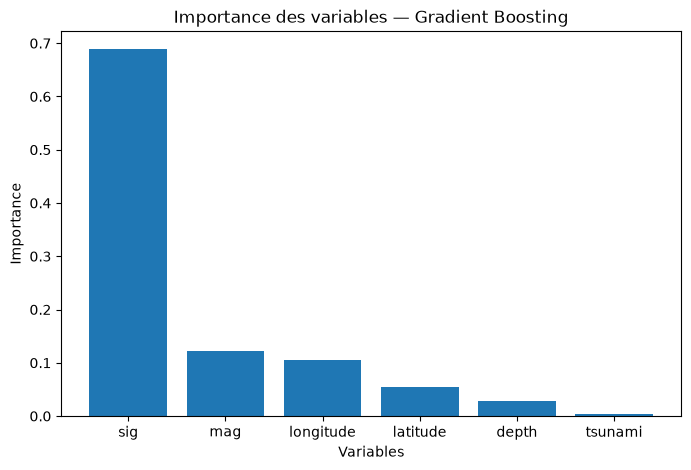

In [94]:
# Visualiser l'importance des variables

plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance['Variable'],
    feature_importance['Importance']
)

plt.title("Importance des variables — Gradient Boosting")
plt.xlabel("Variables")
plt.ylabel("Importance")

plt.show()

**Interprétation du résultat :**

Le graphique confirme que `sig` est la variable qui contribue le plus aux prédictions du modèle Gradient Boosting.

La magnitude et la longitude ont également une contribution visible, mais beaucoup plus faible.

La latitude et la profondeur ont une importance limitée, tandis que `tsunami` contribue très peu aux prédictions.

Ces résultats représentent l'importance des variables dans le modèle et ne signifient pas nécessairement qu'elles causent directement les pertes économiques.

## 50. Comparaison des valeurs réelles et prédites

Je compare les valeurs réelles de la variable cible avec les valeurs prédites par le modèle Gradient Boosting.

Comme le modèle a été entraîné sur une cible logarithmique, je reconvertis les valeurs vers l'échelle originale en dollars afin de faciliter l'interprétation des résultats.

In [95]:
# Reconvertir les valeurs logarithmiques en dollars

y_test_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(y_pred_gb)

# Les pertes économiques ne peuvent pas être négatives
y_pred_dollars = np.maximum(y_pred_dollars, 0)

comparison = pd.DataFrame({
    'Perte réelle ($)': y_test_dollars.values,
    'Perte prédite ($)': y_pred_dollars
})

comparison.head(10)

,Perte réelle ($),Perte prédite ($)
0,0.000000e+00,0.000000e+00
1,0.000000e+00,7.765810e-01
2,0.000000e+00,0.000000e+00
3,0.000000e+00,0.000000e+00
4,0.000000e+00,2.896916e-01
5,0.000000e+00,1.818878e+00
6,0.000000e+00,0.000000e+00
7,0.000000e+00,1.875282e-02
8,1.023897e+10,1.507536e+10
9,0.000000e+00,5.691026e-01


**Interprétation du résultat :**

Les prédictions ont été reconverties de l'échelle logarithmique vers l'échelle originale en dollars.

Pour plusieurs événements dont la perte PAGER est de **0 $**, le modèle prédit également une valeur nulle ou très faible.

Pour l'événement présentant une perte PAGER d'environ **10,24 milliards de dollars**, le modèle prédit environ **15,08 milliards de dollars**.

Le modèle parvient donc à détecter certains événements associés à des pertes économiques très importantes, mais les montants prédits peuvent présenter des écarts importants par rapport aux estimations PAGER.

## 51. Visualisation des valeurs réelles et prédites

Je représente les pertes économiques PAGER et les pertes prédites par le modèle Gradient Boosting.

Un modèle performant devrait produire des prédictions proches des valeurs PAGER correspondantes.

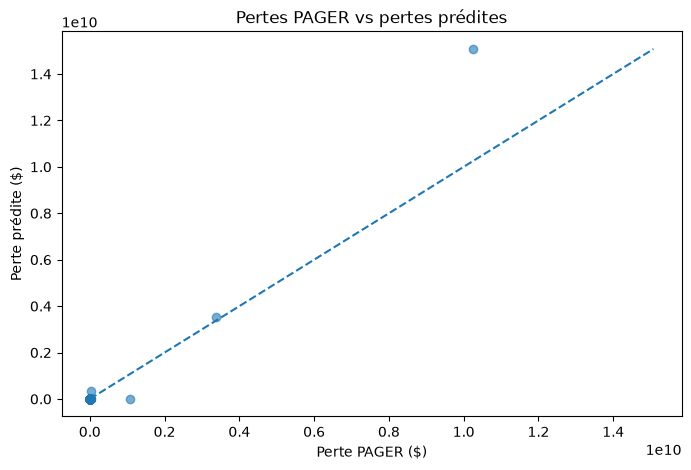

In [96]:
# Comparer les pertes PAGER et les pertes prédites

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test_dollars,
    y_pred_dollars,
    alpha=0.6
)

# Ligne idéale : prédiction = valeur PAGER
max_value = max(y_test_dollars.max(), y_pred_dollars.max())

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle='--'
)

plt.title("Pertes PAGER vs pertes prédites")
plt.xlabel("Perte PAGER ($)")
plt.ylabel("Perte prédite ($)")

plt.show()

**Interprétation du résultat :**

La ligne diagonale représente une prédiction parfaite, où la perte prédite serait exactement égale à la perte estimée par PAGER.

Plus un point est proche de cette ligne, plus la prédiction du modèle est précise.

Le graphique montre que le modèle reproduit assez bien certaines pertes importantes, mais que des écarts subsistent pour certains événements.

La forte concentration des observations près de zéro confirme également que la majorité des séismes du dataset ont une perte économique PAGER nulle ou faible.

## 52. Évaluation du modèle en dollars

Les métriques précédentes ont été calculées sur la variable cible transformée avec `log1p`.

Pour faciliter l'interprétation du modèle, je calcule maintenant les erreurs sur l'échelle originale des pertes économiques, en dollars.

Cette évaluation permettra de mesurer directement l'écart entre les estimations PAGER et les prédictions du modèle.

In [97]:
# Évaluer Gradient Boosting sur l'échelle originale en dollars

mae_dollars = mean_absolute_error(
    y_test_dollars,
    y_pred_dollars
)

rmse_dollars = np.sqrt(
    mean_squared_error(
        y_test_dollars,
        y_pred_dollars
    )
)

print("MAE en dollars  :", round(mae_dollars, 2), "$")
print("RMSE en dollars :", round(rmse_dollars, 2), "$")

MAE en dollars  : 44010119.16 $
RMSE en dollars : 409817278.89 $


**Interprétation du résultat :**

Sur l'échelle originale, le modèle Gradient Boosting obtient une **MAE d'environ 44,01 millions de dollars**.

Cela signifie que l'écart absolu moyen entre les estimations PAGER et les prédictions du modèle est d'environ **44 millions de dollars**.

La **RMSE est d'environ 409,82 millions de dollars**.

La RMSE est beaucoup plus élevée que la MAE parce que cette métrique pénalise davantage les erreurs importantes. Quelques séismes présentant des pertes de plusieurs milliards de dollars ont donc une forte influence sur cette valeur.

Pour cette raison, les métriques calculées sur l'échelle logarithmique restent importantes pour évaluer le modèle sur un dataset aussi asymétrique.

## 53. Sauvegarde du meilleur modèle

Le modèle Gradient Boosting a obtenu les meilleures performances globales parmi les trois algorithmes testés.

Je sauvegarde maintenant ce modèle afin de pouvoir le réutiliser ultérieurement pour effectuer de nouvelles prédictions sans avoir à refaire l'entraînement.

In [98]:
# Sauvegarder le meilleur modèle

model_path = "models/economic_loss_gradient_boosting.pkl"

joblib.dump(
    gradient_boosting_model,
    model_path
)

print("Modèle sauvegardé avec succès.")
print("Emplacement :", model_path)

Modèle sauvegardé avec succès.
Emplacement : models/economic_loss_gradient_boosting.pkl


**Interprétation du résultat :**

Le meilleur modèle, **Gradient Boosting**, a été sauvegardé avec succès dans le dossier `models`.

Le fichier `economic_loss_gradient_boosting.pkl` contient le modèle entraîné.

Il pourra être chargé ultérieurement pour effectuer de nouvelles prédictions sans devoir réentraîner le modèle.

## 54. Vérification du modèle sauvegardé

Je recharge le modèle sauvegardé afin de vérifier que le fichier fonctionne correctement.

Cette étape confirme que le modèle peut être réutilisé pour effectuer de nouvelles prédictions sans refaire l'entraînement.

In [99]:
# Recharger le modèle sauvegardé

loaded_model = joblib.load(
    "models/economic_loss_gradient_boosting.pkl"
)

# Faire une prédiction de test
test_prediction_log = loaded_model.predict(X_test.iloc[[0]])

# Revenir à l'échelle en dollars
test_prediction_dollars = np.expm1(test_prediction_log)

# Éviter une perte négative
test_prediction_dollars = np.maximum(test_prediction_dollars, 0)

print("Modèle chargé avec succès.")
print("Prédiction de test :", round(test_prediction_dollars[0], 2), "$")

Modèle chargé avec succès.
Prédiction de test : 0.0 $


**Interprétation du résultat :**

Le modèle sauvegardé a été rechargé avec succès.

Une prédiction de test a également été effectuée, ce qui confirme que le fichier `.pkl` est fonctionnel.

Pour cette observation, le modèle prédit une perte économique de **0 $**.

Le modèle est maintenant prêt à être réutilisé pour de nouvelles prédictions.

## 55. Conclusion

Dans ce notebook, j'ai développé un modèle de régression pour estimer les pertes économiques associées aux séismes.

Les caractéristiques des séismes proviennent du dataset USGS 2025 et la variable cible `economic_loss` provient des estimations économiques USGS PAGER.

Après le prétraitement, **734 événements** disposaient d'une estimation économique PAGER exploitable.

Trois algorithmes ont été entraînés et comparés : **Régression linéaire**, **Random Forest** et **Gradient Boosting**.

Le modèle **Gradient Boosting** a obtenu les meilleures performances globales avec un **R² de 0,7210** et une **RMSE de 2,2755** sur l'échelle logarithmique.

L'analyse de l'importance des variables montre que `sig` contribue le plus aux prédictions du modèle.

Le modèle final a été sauvegardé dans `economic_loss_gradient_boosting.pkl` et peut être réutilisé pour effectuer de nouvelles prédictions.

Les résultats doivent être interprétés comme une estimation des pertes économiques PAGER et non comme une mesure exacte des pertes économiques réellement observées après chaque séisme.

## 56. Prédiction pour un nouveau séisme

Je teste maintenant le modèle final avec les caractéristiques d'un nouveau séisme.

Les mêmes six variables utilisées pendant l'entraînement doivent être fournies au modèle : `mag`, `depth`, `sig`, `latitude`, `longitude` et `tsunami`.

La prédiction produite par le modèle sera ensuite reconvertie de l'échelle logarithmique vers une estimation en dollars.

In [100]:
# Exemple de nouveau séisme

new_earthquake = pd.DataFrame({
    'mag': [6.5],
    'depth': [20],
    'sig': [650],
    'latitude': [35.0],
    'longitude': [140.0],
    'tsunami': [0]
})

# Prédiction sur l'échelle logarithmique
prediction_log = loaded_model.predict(new_earthquake)

# Revenir à l'échelle en dollars
prediction_dollars = np.expm1(prediction_log)

# Éviter une valeur négative
prediction_dollars = np.maximum(prediction_dollars, 0)

print("Perte économique estimée :", round(prediction_dollars[0], 2), "$")

Perte économique estimée : 29.13 $


**Interprétation du résultat :**

Pour cet exemple, le modèle estime une perte économique d'environ **29,13 $**.

Cette valeur très faible montre une limite importante du modèle.

Le dataset d'entraînement contient **625 événements avec une perte PAGER égale à 0 $ sur 734 observations**. Le modèle a donc appris qu'une grande proportion des séismes sont associés à une perte économique nulle ou très faible.

De plus, les pertes économiques dépendent de facteurs qui ne sont pas directement présents dans les variables utilisées, notamment l'exposition de la population, les infrastructures et la vulnérabilité économique de la région.

Cette prédiction doit donc être considérée comme une estimation expérimentale du modèle et non comme une prévision économique réelle.

## 57. Limites du modèle

Le modèle présente plusieurs limites importantes.

La variable cible provient des **estimations USGS PAGER** et non des pertes économiques finales réellement observées.

De plus, seulement **734 événements** disposent d'une estimation économique exploitable et **625 d'entre eux ont une perte égale à 0 $**.

Les variables utilisées décrivent principalement les caractéristiques du séisme. Le modèle ne dispose pas directement d'informations détaillées sur la population exposée, la valeur des infrastructures, les bâtiments ou la vulnérabilité économique locale.

Les résultats doivent donc être considérés comme une expérimentation de modélisation des estimations PAGER et non comme un système permettant de prévoir exactement les dommages financiers d'un futur séisme.

## 58. Sauvegarde du dataset utilisé pour le modèle

Je sauvegarde le dataset final contenant les événements utilisés pour l'entraînement et l'évaluation du modèle.

Ce fichier permet de conserver les variables explicatives ainsi que la cible économique PAGER utilisée dans cette analyse.

In [102]:
# Sauvegarder le dataset final utilisé pour le modèle

final_dataset_path = "data/economic_loss_model_2025.csv"

df_model.to_csv(
    final_dataset_path,
    index=False
)

print("Dataset final sauvegardé avec succès.")
print("Nombre d'observations :", len(df_model))
print("Emplacement :", final_dataset_path)

Dataset final sauvegardé avec succès.
Nombre d'observations : 734
Emplacement : data/economic_loss_model_2025.csv


**Interprétation du résultat :**

Le dataset final a été sauvegardé avec succès dans le dossier `data`.

Le fichier `economic_loss_model_2025.csv` contient les **734 événements** utilisés pour construire le modèle de prédiction des pertes économiques.

Ce fichier permet de conserver exactement les données utilisées pour l'entraînement et l'évaluation du modèle et facilite la reproductibilité du projet.

In [103]:
# Vérification des séismes avec les pertes PAGER les plus élevées

df_model.sort_values(
    "economic_loss",
    ascending=False
)[
    [
        "mag",
        "depth",
        "sig",
        "latitude",
        "longitude",
        "tsunami",
        "economic_loss"
    ]
].head(10)

,mag,depth,sig,latitude,longitude,tsunami,economic_loss
6381,7.7,10.000,2910,22.0110,95.9363,0,5.299175e+10
25941,8.8,35.000,2114,52.4948,160.2395,1,1.023897e+10
27182,7.4,34.000,2018,52.8301,160.6816,1,3.364213e+09
12302,7.1,10.000,2787,28.6036,87.3781,0,1.149651e+09
6380,6.7,10.000,2105,21.6975,95.9690,0,1.083286e+09
23481,6.1,10.000,1188,39.3709,28.0168,0,5.528507e+08
4472,6.2,12.736,1684,40.8342,28.1897,0,4.842771e+08
21828,6.0,8.000,2149,34.7106,70.8087,0,4.037929e+08
19615,6.9,10.000,1592,11.1557,124.1110,1,2.922541e+08
20788,5.5,29.000,1072,26.7097,92.2103,0,2.836755e+08


In [104]:
import requests

event_id = "us6000qw60"

url = (
    f"https://earthquake.usgs.gov/fdsnws/event/1/query"
    f"?eventid={event_id}&format=geojson"
)

response = requests.get(url, timeout=30)
response.raise_for_status()

if not response.text.strip():
    raise RuntimeError("USGS returned an empty response")

event_data = response.json()

products = event_data["properties"]["products"]

print(products.keys())

dict_keys(['dyfi', 'earthquake-name', 'event-sequence', 'finite-fault', 'general-link', 'general-text', 'ground-failure', 'impact-link', 'impact-text', 'internal-moment-tensor', 'internal-origin', 'losspager', 'moment-tensor', 'oaf', 'origin', 'phase-data', 'shakemap'])


In [105]:
losspager = products["losspager"][0]

print(losspager["contents"].keys())

dict_keys(['json/cities.json', 'onepager.pdf', 'alertecon.png', 'json/comments.json', 'exposure.png', 'alertfatal_small.png', 'json/alerts.json', 'json/exposures.json', 'json/historical_earthquakes.json', 'alertecon.pdf', 'grid.xml', 'onepager.aux', 'contents.xml', 'exposure.pdf', 'json/losses.json', 'alertfatal.pdf', 'alertfatal_smaller.png', 'json/event.json', 'onepager.tex', 'pager.xml', 'alertecon_small.png', 'alertecon_smaller.png', 'alertfatal.png'])


In [106]:
exposures_url = losspager["contents"]["json/exposures.json"]["url"]

exposures_data = requests.get(exposures_url).json()

exposures_data.keys()

dict_keys(['population_exposure', 'economic_exposure'])

In [107]:
population_exposure = exposures_data["population_exposure"]

type(population_exposure), population_exposure

(dict,
 {'mmi': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
  'aggregated_exposure': [0,
   0,
   1764,
   9758,
   13519,
   5957,
   214211,
   56344,
   1802,
   0],
  'maximum_border_mmi': 4.099999904632569,
  'country_exposures': [{'country_code': 'RU',
    'exposure': [0, 0, 1764, 9758, 13519, 5957, 214211, 56344, 1802, 0]}]})

In [108]:
economic_exposure = exposures_data["economic_exposure"]

type(economic_exposure), economic_exposure

(dict,
 {'mmi': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
  'aggregated_exposure': [0.0,
   0.0,
   491110258.9552571,
   2716697226.1255093,
   3763786616.108912,
   1658471549.0909674,
   59637879637.79171,
   15686573940.235264,
   501689731.65383977,
   0.0],
  'country_exposures': [{'country_code': 'RU',
    'exposure': [0.0,
     0.0,
     491110258.9552571,
     2716697226.1255093,
     3763786616.108912,
     1658471549.0909674,
     59637879637.79171,
     15686573940.235264,
     501689731.65383977,
     0.0]}]})

In [111]:
economic = losses_data["empirical_economic"]

print(economic.keys())

dict_keys(['total_dollars', 'country_dollars'])


In [112]:
print("Total economic loss:")
print(economic["total_dollars"])

print("\nEconomic loss by country:")
print(economic["country_dollars"])

Total economic loss:
10238972670

Economic loss by country:
[{'country_code': 'RU', 'rates': [2.0991953314921798e-91, 2.5310497412664658e-42, 1.7017430886602766e-22, 2.196519097843858e-12, 8.754773553956376e-07, 0.0012280277383668343, 0.06083405411828719, 0.39550427673667554, 0.8068964192106685, 0.9698567834013938], 'us_dollars': 10238972670}]


In [113]:
event_url = losspager["contents"]["json/event.json"]["url"]

event_pager = requests.get(event_url).json()

print(event_pager.keys())

dict_keys(['event', 'pager', 'shakemap'])


In [114]:
shakemap_data = event_pager["shakemap"]

print(shakemap_data.keys())

dict_keys(['shake_version', 'shake_code_version', 'shake_processing_time', 'shake_source', 'shake_id', 'shake_type'])


In [115]:
pager_data = event_pager["pager"]

print(pager_data.keys())

dict_keys(['software_version', 'processing_time', 'version_number', 'eventcode', 'versioncode', 'alert_level', 'true_alert_level', 'maxmmi', 'elapsed_time', 'local_time_string'])


In [116]:
event_data = event_pager["event"]

print(event_data.keys())

dict_keys(['eventid', 'versionid', 'time', 'lat', 'lon', 'depth', 'mag', 'location', 'tsunami'])


In [117]:
# Vérifier la disponibilité des données PAGER pour plusieurs événements

import requests
import time

sample_events = df_model["event_id"].dropna().head(20).tolist()

results = []

for event_id in sample_events:

    url = (
        "https://earthquake.usgs.gov/fdsnws/event/1/query"
        f"?eventid={event_id}&format=geojson"
    )

    try:
        response = requests.get(url, timeout=20)
        data = response.json()

        products = data["properties"].get("products", {})

        has_losspager = "losspager" in products

        has_exposures = False
        has_losses = False

        if has_losspager:

            contents = products["losspager"][0].get("contents", {})

            has_exposures = (
                "json/exposures.json" in contents
            )

            has_losses = (
                "json/losses.json" in contents
            )

        results.append({
            "event_id": event_id,
            "losspager": has_losspager,
            "exposures": has_exposures,
            "losses": has_losses
        })

    except Exception as e:

        results.append({
            "event_id": event_id,
            "losspager": False,
            "exposures": False,
            "losses": False
        })

    time.sleep(0.2)


pager_availability = pd.DataFrame(results)

pager_availability

,event_id,losspager,exposures,losses
0,us7000q9fs,True,True,True
1,us7000q9f3,True,True,True
2,us7000q9b5,True,True,True
3,us7000q99p,True,True,True
4,us7000q97d,True,True,True
5,us7000q8tw,True,True,True
6,us7000q8l7,True,True,True
7,pr2025175000,True,True,True
8,us7000q8be,True,True,True
9,us7000q8bd,True,True,True


In [118]:
print(
    "Événements testés :",
    len(pager_availability)
)

print(
    "Avec PAGER :",
    pager_availability["losspager"].sum()
)

print(
    "Avec exposures.json :",
    pager_availability["exposures"].sum()
)

print(
    "Avec losses.json :",
    pager_availability["losses"].sum()
)

Événements testés : 20
Avec PAGER : 20
Avec exposures.json : 20
Avec losses.json : 20


In [ ]:
# ============================================================
# CONSTRUCTION DU DATASET PAGER POUR LE MODÈLE V2
# ============================================================

import requests
import time

pager_rows = []

event_ids = df_model["event_id"].dropna().unique()

print("Nombre d'événements à traiter :", len(event_ids))

for i, event_id in enumerate(event_ids, start=1):

    url = (
        "https://earthquake.usgs.gov/fdsnws/event/1/query"
        f"?eventid={event_id}&format=geojson"
    )

    try:

        response = requests.get(
            url,
            timeout=20
        )

        data = response.json()

        properties = data["properties"]

        products = properties.get(
            "products",
            {}
        )

        if "losspager" not in products:
            continue

        losspager = products["losspager"][0]

        contents = losspager.get(
            "contents",
            {}
        )

        if (
            "json/exposures.json" not in contents
            or
            "json/losses.json" not in contents
        ):
            continue

        # ----------------------------------------------------
        # EXPOSURE
        # ----------------------------------------------------

        exposures_url = contents[
            "json/exposures.json"
        ]["url"]

        exposures = requests.get(
            exposures_url,
            timeout=20
        ).json()

        population = exposures.get(
            "population_exposure",
            {}
        )

        economic = exposures.get(
            "economic_exposure",
            {}
        )

        population_values = population.get(
            "aggregated_exposure",
            []
        )

        economic_values = economic.get(
            "aggregated_exposure",
            []
        )

        # ----------------------------------------------------
        # LOSSES
        # ----------------------------------------------------

        losses_url = contents[
            "json/losses.json"
        ]["url"]

        losses = requests.get(
            losses_url,
            timeout=20
        ).json()

        empirical_economic = losses.get(
            "empirical_economic",
            {}
        )

        total_loss = empirical_economic.get(
            "total_dollars"
        )

        if total_loss is None:
            continue

        # ----------------------------------------------------
        # EVENT / PAGER INFORMATION
        # ----------------------------------------------------

        event_url = contents[
            "json/event.json"
        ]["url"]

        event_info = requests.get(
            event_url,
            timeout=20
        ).json()

        event_data = event_info.get(
            "event",
            {}
        )

        pager_data = event_info.get(
            "pager",
            {}
        )

        row = {
            "event_id": event_id,

            "mag": event_data.get("mag"),
            "depth": event_data.get("depth"),
            "latitude": event_data.get("lat"),
            "longitude": event_data.get("lon"),
            "tsunami": event_data.get("tsunami"),

            "maxmmi": pager_data.get("maxmmi"),

            "economic_loss": total_loss
        }

        # ----------------------------------------------------
        # POPULATION EXPOSURE BY MMI
        # ----------------------------------------------------

        for mmi in range(5, 11):

            index = mmi - 1

            if index < len(population_values):
                row[
                    f"population_mmi_{mmi}"
                ] = population_values[index]
            else:
                row[
                    f"population_mmi_{mmi}"
                ] = 0

        # ----------------------------------------------------
        # ECONOMIC EXPOSURE BY MMI
        # ----------------------------------------------------

        for mmi in range(5, 11):

            index = mmi - 1

            if index < len(economic_values):
                row[
                    f"economic_exposure_mmi_{mmi}"
                ] = economic_values[index]
            else:
                row[
                    f"economic_exposure_mmi_{mmi}"
                ] = 0

        pager_rows.append(row)

    except Exception as e:

        print(
            f"Erreur pour {event_id}: {e}"
        )

    if i % 100 == 0:

        print(
            f"{i} événements traités — "
            f"{len(pager_rows)} lignes valides"
        )

    time.sleep(0.15)


pager_v2 = pd.DataFrame(
    pager_rows
)

print(
    "\nDataset V2 créé :",
    pager_v2.shape
)

Nombre d'événements à traiter : 734
100 événements traités — 100 lignes valides
200 événements traités — 200 lignes valides
300 événements traités — 300 lignes valides
500 événements traités — 500 lignes valides
600 événements traités — 600 lignes valides


In [2]:
import pandas as pd
import requests
import time
import os

PROGRESS_FILE = "data/pager_v2_progress.csv"

print("Fichier de progression :", PROGRESS_FILE)

Fichier de progression : data/pager_v2_progress.csv


In [5]:
import pandas as pd

df_model = pd.read_csv("data/economic_loss_model_2025.csv")

print("Dataset chargé :", df_model.shape)
print(df_model.columns.tolist())

Dataset chargé : (734, 9)
['event_id', 'mag', 'depth', 'sig', 'latitude', 'longitude', 'tsunami', 'place', 'economic_loss']


In [6]:
import pandas as pd
import requests
import time
import os

PROGRESS_FILE = "data/pager_v2_progress.csv"

print("Prêt.")
print("Fichier de sauvegarde :", PROGRESS_FILE)

Prêt.
Fichier de sauvegarde : data/pager_v2_progress.csv


In [7]:
if os.path.exists(PROGRESS_FILE):

    pager_v2 = pd.read_csv(PROGRESS_FILE)

    completed_ids = set(
        pager_v2["event_id"].astype(str)
    )

    print("Progression trouvée :", len(pager_v2))

else:

    pager_v2 = pd.DataFrame()
    completed_ids = set()

    print("Aucune progression précédente.")

Aucune progression précédente.


In [8]:
event_ids = df_model["event_id"].dropna().astype(str).unique()

remaining_ids = [
    event_id
    for event_id in event_ids
    if event_id not in completed_ids
]

print("Total événements :", len(event_ids))
print("Déjà récupérés :", len(completed_ids))
print("Restants à traiter :", len(remaining_ids))

Total événements : 734
Déjà récupérés : 0
Restants à traiter : 734


In [9]:
event_id = remaining_ids[0]

url = (
    "https://earthquake.usgs.gov/fdsnws/event/1/query"
    f"?eventid={event_id}&format=geojson"
)

response = requests.get(url, timeout=20)
response.raise_for_status()

data = response.json()

products = data["properties"].get("products", {})

print("Event ID :", event_id)
print("PAGER disponible :", "losspager" in products)

Event ID : us7000q9fs
PAGER disponible : True


In [10]:
losspager = products["losspager"][0]

contents = losspager.get("contents", {})

print(
    "exposures.json :",
    "json/exposures.json" in contents
)

print(
    "losses.json :",
    "json/losses.json" in contents
)

print(
    "event.json :",
    "json/event.json" in contents
)

exposures.json : True
losses.json : True
event.json : True


In [11]:
exposures_url = contents["json/exposures.json"]["url"]

response = requests.get(
    exposures_url,
    timeout=20
)

response.raise_for_status()

exposures = response.json()

population = exposures["population_exposure"]
economic = exposures["economic_exposure"]

population_values = population["aggregated_exposure"]
economic_values = economic["aggregated_exposure"]

print("MMI :", population["mmi"])
print("Population :", population_values)
print("Exposition économique :", economic_values)

MMI : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Population : [0, 5365, 120245, 201, 0, 0, 0, 0, 0, 0]
Exposition économique : [0.0, 2600091484.1643734, 58275489378.06991, 97412560.7301098, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [12]:
losses_url = contents["json/losses.json"]["url"]

response = requests.get(
    losses_url,
    timeout=20
)

response.raise_for_status()

losses = response.json()

economic_loss = (
    losses
    .get("empirical_economic", {})
    .get("total_dollars")
)

print("Event ID :", event_id)
print("Economic loss :", economic_loss)
print("Economic loss ($) :", f"${economic_loss:,.2f}")

Event ID : us7000q9fs
Economic loss : 0
Economic loss ($) : $0.00


In [13]:
event_url = contents["json/event.json"]["url"]

response = requests.get(
    event_url,
    timeout=20
)

response.raise_for_status()

event_info = response.json()

event_details = event_info["event"]
pager_details = event_info["pager"]

print("Magnitude :", event_details["mag"])
print("Depth :", event_details["depth"])
print("Tsunami :", event_details["tsunami"])
print("Maximum MMI :", pager_details["maxmmi"])

Magnitude : 5.4
Depth : 10.0
Tsunami : 0
Maximum MMI : 3


In [14]:
row = {
    "event_id": event_id,
    "mag": event_details["mag"],
    "depth": event_details["depth"],
    "tsunami": event_details["tsunami"],
    "maxmmi": pager_details["maxmmi"],
    "economic_loss": economic_loss
}

# Population exposure MMI 5 → 10
for mmi in range(5, 11):

    index = mmi - 1

    row[f"population_mmi_{mmi}"] = (
        population_values[index]
        if index < len(population_values)
        else 0
    )

# Economic exposure MMI 5 → 10
for mmi in range(5, 11):

    index = mmi - 1

    row[f"economic_exposure_mmi_{mmi}"] = (
        economic_values[index]
        if index < len(economic_values)
        else 0
    )

test_v2 = pd.DataFrame([row])

test_v2.T

,0
event_id,us7000q9fs
mag,5.4
depth,10.0
tsunami,0
maxmmi,3
economic_loss,0
population_mmi_5,0
population_mmi_6,0
population_mmi_7,0
population_mmi_8,0


In [15]:
def extract_pager_v2(event_id):

    # USGS event
    url = (
        "https://earthquake.usgs.gov/fdsnws/event/1/query"
        f"?eventid={event_id}&format=geojson"
    )

    response = requests.get(url, timeout=20)
    response.raise_for_status()

    data = response.json()

    products = data["properties"].get("products", {})

    if "losspager" not in products:
        return None

    losspager = products["losspager"][0]
    contents = losspager.get("contents", {})

    # Required PAGER files
    required = [
        "json/exposures.json",
        "json/losses.json",
        "json/event.json"
    ]

    if not all(file in contents for file in required):
        return None

    # -----------------------------
    # EXPOSURES
    # -----------------------------

    url_exposure = contents["json/exposures.json"]["url"]

    response = requests.get(url_exposure, timeout=20)
    response.raise_for_status()

    exposures = response.json()

    population_values = (
        exposures
        .get("population_exposure", {})
        .get("aggregated_exposure", [])
    )

    economic_values = (
        exposures
        .get("economic_exposure", {})
        .get("aggregated_exposure", [])
    )

    # -----------------------------
    # ECONOMIC LOSS
    # -----------------------------

    url_losses = contents["json/losses.json"]["url"]

    response = requests.get(url_losses, timeout=20)
    response.raise_for_status()

    losses = response.json()

    economic_loss = (
        losses
        .get("empirical_economic", {})
        .get("total_dollars")
    )

    if economic_loss is None:
        return None

    # -----------------------------
    # EVENT INFORMATION
    # -----------------------------

    url_event = contents["json/event.json"]["url"]

    response = requests.get(url_event, timeout=20)
    response.raise_for_status()

    info = response.json()

    event = info.get("event", {})
    pager = info.get("pager", {})

    row = {
        "event_id": event_id,
        "mag": event.get("mag"),
        "depth": event.get("depth"),
        "tsunami": event.get("tsunami"),
        "maxmmi": pager.get("maxmmi"),
        "economic_loss": economic_loss
    }

    # MMI 5 → 10
    for mmi in range(5, 11):

        index = mmi - 1

        row[f"population_mmi_{mmi}"] = (
            population_values[index]
            if index < len(population_values)
            else 0
        )

        row[f"economic_exposure_mmi_{mmi}"] = (
            economic_values[index]
            if index < len(economic_values)
            else 0
        )

    return row

In [16]:
test_row = extract_pager_v2(
    remaining_ids[0]
)

test_row

{'event_id': 'us7000q9fs',
 'mag': 5.4,
 'depth': 10.0,
 'tsunami': 0,
 'maxmmi': 3,
 'economic_loss': 0,
 'population_mmi_5': 0,
 'economic_exposure_mmi_5': 0.0,
 'population_mmi_6': 0,
 'economic_exposure_mmi_6': 0.0,
 'population_mmi_7': 0,
 'economic_exposure_mmi_7': 0.0,
 'population_mmi_8': 0,
 'economic_exposure_mmi_8': 0.0,
 'population_mmi_9': 0,
 'economic_exposure_mmi_9': 0.0,
 'population_mmi_10': 0,
 'economic_exposure_mmi_10': 0.0}

In [17]:
pager_rows = []

for i, event_id in enumerate(remaining_ids, start=1):

    try:
        row = extract_pager_v2(event_id)

        if row is not None:
            pager_rows.append(row)

    except Exception as e:
        print(f"Erreur {event_id} : {e}")

    # Sauvegarde tous les 25 événements
    if i % 25 == 0:

        current_df = pd.DataFrame(pager_rows)

        current_df.to_csv(
            PROGRESS_FILE,
            index=False
        )

        print(
            f"{i}/{len(remaining_ids)} traités "
            f"— {len(current_df)} sauvegardés"
        )

    time.sleep(0.15)


# Sauvegarde finale
pager_v2 = pd.DataFrame(pager_rows)

pager_v2.to_csv(
    PROGRESS_FILE,
    index=False
)

print("\nExtraction terminée")
print("Dataset V2 :", pager_v2.shape)
print("Fichier :", PROGRESS_FILE)

25/734 traités — 25 sauvegardés
50/734 traités — 50 sauvegardés
75/734 traités — 75 sauvegardés
100/734 traités — 100 sauvegardés
125/734 traités — 125 sauvegardés
150/734 traités — 150 sauvegardés
175/734 traités — 175 sauvegardés
200/734 traités — 200 sauvegardés
225/734 traités — 225 sauvegardés
250/734 traités — 250 sauvegardés
275/734 traités — 275 sauvegardés
300/734 traités — 300 sauvegardés
325/734 traités — 325 sauvegardés
350/734 traités — 350 sauvegardés
375/734 traités — 375 sauvegardés
400/734 traités — 400 sauvegardés
425/734 traités — 425 sauvegardés
450/734 traités — 450 sauvegardés
475/734 traités — 475 sauvegardés
500/734 traités — 500 sauvegardés
525/734 traités — 525 sauvegardés
550/734 traités — 550 sauvegardés
575/734 traités — 575 sauvegardés
600/734 traités — 600 sauvegardés
625/734 traités — 625 sauvegardés
650/734 traités — 650 sauvegardés
675/734 traités — 675 sauvegardés
700/734 traités — 700 sauvegardés
725/734 traités — 725 sauvegardés

Extraction terminée

In [18]:
print("Dimensions :", pager_v2.shape)

print("\nValeurs manquantes :")
print(
    pager_v2.isnull().sum()
)

Dimensions : (734, 18)

Valeurs manquantes :
event_id                    0
mag                         0
depth                       0
tsunami                     0
maxmmi                      0
economic_loss               0
population_mmi_5            0
economic_exposure_mmi_5     0
population_mmi_6            0
economic_exposure_mmi_6     0
population_mmi_7            0
economic_exposure_mmi_7     0
population_mmi_8            0
economic_exposure_mmi_8     0
population_mmi_9            0
economic_exposure_mmi_9     0
population_mmi_10           0
economic_exposure_mmi_10    0
dtype: int64


In [19]:
for mmi in range(5, 11):

    pop_col = f"population_mmi_{mmi}"
    eco_col = f"economic_exposure_mmi_{mmi}"

    pop_count = (pager_v2[pop_col] > 0).sum()
    eco_count = (pager_v2[eco_col] > 0).sum()

    print(
        f"MMI {mmi} : "
        f"Population > 0 = {pop_count} | "
        f"Exposition économique > 0 = {eco_count}"
    )

MMI 5 : Population > 0 = 178 | Exposition économique > 0 = 178
MMI 6 : Population > 0 = 101 | Exposition économique > 0 = 101
MMI 7 : Population > 0 = 54 | Exposition économique > 0 = 54
MMI 8 : Population > 0 = 25 | Exposition économique > 0 = 25
MMI 9 : Population > 0 = 7 | Exposition économique > 0 = 7
MMI 10 : Population > 0 = 1 | Exposition économique > 0 = 1


In [20]:
zero_loss = (pager_v2["economic_loss"] == 0).sum()
positive_loss = (pager_v2["economic_loss"] > 0).sum()

print("Total :", len(pager_v2))
print("Perte = $0 :", zero_loss)
print("Perte > $0 :", positive_loss)

print("\nPourcentages :")
print(
    "Perte = $0 :",
    round(zero_loss / len(pager_v2) * 100, 2),
    "%"
)

print(
    "Perte > $0 :",
    round(positive_loss / len(pager_v2) * 100, 2),
    "%"
)

print("\nStatistiques des pertes positives :")

print(
    pager_v2.loc[
        pager_v2["economic_loss"] > 0,
        "economic_loss"
    ].describe()
)

Total : 734
Perte = $0 : 625
Perte > $0 : 109

Pourcentages :
Perte = $0 : 85.15 %
Perte > $0 : 14.85 %

Statistiques des pertes positives :
count    1.090000e+02
mean     6.571125e+08
std      5.164561e+09
min      1.000000e+00
25%      5.000000e+01
50%      2.117300e+04
75%      4.824051e+06
max      5.299175e+10
Name: economic_loss, dtype: float64


## Modèle économique V2 — Approche en deux étapes

L'analyse de la variable cible montre que les pertes économiques sont très déséquilibrées.

Sur 734 séismes :

- 625 événements ont une perte économique estimée à 0 $.
- 109 événements ont une perte économique supérieure à 0 $.
- Environ 85 % des observations ont donc une perte nulle.

De plus, les pertes positives présentent une très grande variation, allant de quelques dollars à plusieurs milliards de dollars.

Pour mieux représenter ce problème, le modèle V2 sera divisé en deux étapes :

1. **Classification** : déterminer si un séisme entraîne une perte économique (`0 = Non`, `1 = Oui`).
2. **Régression** : lorsque la perte est positive, estimer le montant de cette perte.

Cette approche permet de séparer la détection d'un impact économique de l'estimation de son montant.

In [22]:
pager_v2["has_economic_loss"] = (
    pager_v2["economic_loss"] > 0
).astype(int)

print(
    pager_v2["has_economic_loss"].value_counts()
)

print("\nPourcentages :")

print(
    pager_v2["has_economic_loss"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

has_economic_loss
0    625
1    109
Name: count, dtype: int64

Pourcentages :
has_economic_loss
0    85.15
1    14.85
Name: proportion, dtype: float64


## Étape 1 — Sélection des variables explicatives

La première étape du modèle V2 consiste à prédire si un séisme entraîne une perte économique.

La variable cible est :

- `has_economic_loss = 0` : aucune perte économique estimée.
- `has_economic_loss = 1` : présence d'une perte économique.

Les variables explicatives utilisées représentent les caractéristiques physiques du séisme ainsi que l'exposition de la population et des biens aux différents niveaux d'intensité MMI.

Les variables retenues sont :

- Magnitude du séisme.
- Profondeur.
- Intensité maximale MMI.
- Population exposée aux niveaux MMI 5 à 10.
- Exposition économique aux niveaux MMI 5 à 10.

La variable `sig` du modèle précédent n'est pas utilisée dans cette version afin d'évaluer davantage l'apport des données physiques et d'exposition issues de PAGER.

In [23]:
features_v2 = [
    "mag",
    "depth",
    "maxmmi",

    "population_mmi_5",
    "population_mmi_6",
    "population_mmi_7",
    "population_mmi_8",
    "population_mmi_9",
    "population_mmi_10",

    "economic_exposure_mmi_5",
    "economic_exposure_mmi_6",
    "economic_exposure_mmi_7",
    "economic_exposure_mmi_8",
    "economic_exposure_mmi_9",
    "economic_exposure_mmi_10"
]

X = pager_v2[features_v2]
y = pager_v2["has_economic_loss"]

print("X :", X.shape)
print("y :", y.shape)

print("\nVariables utilisées :")
for feature in features_v2:
    print("-", feature)

X : (734, 15)
y : (734,)

Variables utilisées :
- mag
- depth
- maxmmi
- population_mmi_5
- population_mmi_6
- population_mmi_7
- population_mmi_8
- population_mmi_9
- population_mmi_10
- economic_exposure_mmi_5
- economic_exposure_mmi_6
- economic_exposure_mmi_7
- economic_exposure_mmi_8
- economic_exposure_mmi_9
- economic_exposure_mmi_10


## Séparation des données en ensembles d'entraînement et de test

Les données sont divisées en deux ensembles :

- **80 % pour l'entraînement** du modèle.
- **20 % pour le test** du modèle.

La variable cible est déséquilibrée : seulement 14,85 % des séismes présentent une perte économique positive.

Pour cette raison, une séparation **stratifiée** est utilisée. Elle permet de conserver approximativement la même proportion de séismes avec et sans perte économique dans les ensembles d'entraînement et de test.

Le paramètre `random_state=42` est utilisé afin de rendre la séparation reproductible.

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

print("\nDistribution entraînement :")
print(y_train.value_counts())

print("\nDistribution test :")
print(y_test.value_counts())

X_train : (587, 15)
X_test  : (147, 15)

Distribution entraînement :
has_economic_loss
0    500
1     87
Name: count, dtype: int64

Distribution test :
has_economic_loss
0    125
1     22
Name: count, dtype: int64


## Modèle 1 — Régression logistique

La régression logistique est utilisée comme premier modèle de classification.

Son objectif est de prédire si un séisme entraîne une perte économique :

- `0` : aucune perte économique.
- `1` : perte économique positive.

Comme les deux classes sont déséquilibrées, le paramètre `class_weight="balanced"` est utilisé. Il donne davantage d'importance à la classe minoritaire afin que le modèle prenne mieux en compte les séismes associés à une perte économique.

La régression logistique servira également de modèle de référence pour comparer les performances avec des modèles plus complexes.

In [26]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

logistic_model.fit(
    X_train,
    y_train
)

print("Modèle entraîné avec succès.")

Modèle entraîné avec succès.


## Évaluation du modèle de régression logistique

Le modèle est maintenant évalué sur l'ensemble de test.

Plusieurs métriques sont utilisées :

- **Accuracy** : proportion totale de prédictions correctes.
- **Precision** : parmi les événements prédits avec une perte économique, proportion réellement associée à une perte.
- **Recall (sensibilité)** : proportion des événements avec une perte économique réellement détectés par le modèle.
- **F1-score** : compromis entre la précision et le recall.

Dans ce projet, le **recall de la classe 1** est particulièrement important, car il indique la capacité du modèle à détecter les séismes associés à une perte économique.

La matrice de confusion permet également d'observer les vrais positifs, vrais négatifs, faux positifs et faux négatifs.

In [27]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

y_pred_logistic = logistic_model.predict(X_test)

accuracy_logistic = accuracy_score(
    y_test,
    y_pred_logistic
)

print(
    "Accuracy :",
    round(accuracy_logistic, 4)
)

print("\nClassification Report :")
print(
    classification_report(
        y_test,
        y_pred_logistic,
        digits=4
    )
)

print("Matrice de confusion :")
print(
    confusion_matrix(
        y_test,
        y_pred_logistic
    )
)

Accuracy : 0.9524

Classification Report :
              precision    recall  f1-score   support

           0     0.9683    0.9760    0.9721       125
           1     0.8571    0.8182    0.8372        22

    accuracy                         0.9524       147
   macro avg     0.9127    0.8971    0.9047       147
weighted avg     0.9516    0.9524    0.9519       147

Matrice de confusion :
[[122   3]
 [  4  18]]


## Modèle 2 — Random Forest

Le deuxième modèle testé est le **Random Forest Classifier**.

Random Forest combine plusieurs arbres de décision afin de produire une prédiction plus robuste. Contrairement à la régression logistique, il peut représenter des relations non linéaires et des interactions plus complexes entre les caractéristiques du séisme, l'intensité MMI et les variables d'exposition.

Le paramètre `class_weight="balanced"` est utilisé afin de tenir compte du déséquilibre entre les séismes sans perte économique et ceux associés à une perte positive.

Les performances de ce modèle seront comparées à celles de la régression logistique sur le même ensemble de test.

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_classifier.fit(
    X_train,
    y_train
)

print("Random Forest entraîné avec succès.")

Random Forest entraîné avec succès.


## Évaluation du modèle Random Forest

Le modèle Random Forest est évalué sur le même ensemble de test que la régression logistique.

Cette évaluation permet de comparer directement les deux modèles.

Une attention particulière est portée aux performances de la classe `1`, qui représente les séismes associés à une perte économique positive.

Les principales métriques observées sont la précision, le recall et le F1-score. La matrice de confusion permet également d'identifier le nombre de pertes correctement détectées et le nombre de pertes non détectées.

In [29]:
y_pred_rf = rf_classifier.predict(X_test)

accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

print(
    "Accuracy :",
    round(accuracy_rf, 4)
)

print("\nClassification Report :")
print(
    classification_report(
        y_test,
        y_pred_rf,
        digits=4
    )
)

print("Matrice de confusion :")
print(
    confusion_matrix(
        y_test,
        y_pred_rf
    )
)

Accuracy : 0.9524

Classification Report :
              precision    recall  f1-score   support

           0     0.9758    0.9680    0.9719       125
           1     0.8261    0.8636    0.8444        22

    accuracy                         0.9524       147
   macro avg     0.9009    0.9158    0.9082       147
weighted avg     0.9534    0.9524    0.9528       147

Matrice de confusion :
[[121   4]
 [  3  19]]


## Modèle 3 — Gradient Boosting

Le troisième modèle testé est le **Gradient Boosting Classifier**.

Le Gradient Boosting construit progressivement plusieurs arbres de décision. Chaque nouvel arbre cherche à corriger une partie des erreurs produites par les arbres précédents.

Ce modèle peut représenter des relations non linéaires entre la magnitude, la profondeur, l'intensité MMI et les différentes variables d'exposition.

Il sera entraîné et évalué sur les mêmes données que les deux modèles précédents afin de permettre une comparaison cohérente des performances.

In [30]:
from sklearn.ensemble import GradientBoostingClassifier

gb_classifier = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_classifier.fit(
    X_train,
    y_train
)

print("Gradient Boosting entraîné avec succès.")

Gradient Boosting entraîné avec succès.


## Évaluation du modèle Gradient Boosting

Le modèle Gradient Boosting est évalué sur le même ensemble de test que les modèles précédents.

Les performances seront mesurées avec :

- l'accuracy globale ;
- la précision ;
- le recall ;
- le F1-score ;
- la matrice de confusion.

Une attention particulière est portée au **recall de la classe 1**, car il mesure la capacité du modèle à détecter les séismes associés à une perte économique positive.

Les résultats seront ensuite comparés à ceux de la régression logistique et du Random Forest.

In [32]:
y_pred_gb = gb_classifier.predict(X_test)

accuracy_gb = accuracy_score(
    y_test,
    y_pred_gb
)

print(
    "Accuracy :",
    round(accuracy_gb, 4)
)

print("\nClassification Report :")
print(
    classification_report(
        y_test,
        y_pred_gb,
        digits=4
    )
)

print("Matrice de confusion :")
print(
    confusion_matrix(
        y_test,
        y_pred_gb
    )
)

Accuracy : 0.9524

Classification Report :
              precision    recall  f1-score   support

           0     0.9683    0.9760    0.9721       125
           1     0.8571    0.8182    0.8372        22

    accuracy                         0.9524       147
   macro avg     0.9127    0.8971    0.9047       147
weighted avg     0.9516    0.9524    0.9519       147

Matrice de confusion :
[[122   3]
 [  4  18]]


## Comparaison des modèles de classification

Trois algorithmes ont été évalués sur le même ensemble de test : la régression logistique, Random Forest et Gradient Boosting.

Les trois modèles obtiennent une accuracy globale de 95,24 %. Cependant, l'accuracy seule n'est pas suffisante dans ce problème, car la classe représentant les pertes économiques positives est minoritaire.

Random Forest détecte 19 des 22 événements avec une perte économique positive, contre 18 pour les deux autres modèles. Il obtient ainsi un recall de 86,36 % pour la classe 1.

La précision de Random Forest est légèrement plus faible, ce qui signifie qu'il génère un faux positif supplémentaire. Son F1-score pour la classe 1 est cependant légèrement supérieur à celui des deux autres modèles.

Cette comparaison montre l'importance d'utiliser plusieurs métriques dans un problème de classification déséquilibré.

In [34]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

comparison_classification = pd.DataFrame({
    "Modèle": [
        "Régression logistique",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],

    "Precision classe 1": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb)
    ],

    "Recall classe 1": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb)
    ],

    "F1 classe 1": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ]
})

comparison_classification.round(4)

,Modèle,Accuracy,Precision classe 1,Recall classe 1,F1 classe 1
0,Régression logistique,0.9524,0.8571,0.8182,0.8372
1,Random Forest,0.9524,0.8261,0.8636,0.8444
2,Gradient Boosting,0.9524,0.8571,0.8182,0.8372


## Étape 2 — Estimation du montant des pertes économiques

Après avoir déterminé si un séisme est associé à une perte économique, la deuxième étape consiste à estimer le montant de cette perte.

Pour cette étape, seuls les séismes ayant une perte économique strictement supérieure à zéro sont utilisés.

Le dataset contient 109 événements avec une perte économique positive.

Les montants présentent une très grande variation, allant de quelques dollars à plusieurs milliards de dollars. Cette forte asymétrie devra être prise en compte lors de l'entraînement des modèles de régression.

La variable cible de cette étape est `economic_loss`.

In [36]:
pager_positive = pager_v2[
    pager_v2["economic_loss"] > 0
].copy()

print(
    "Nombre d'événements avec perte positive :",
    len(pager_positive)
)

print("\nStatistiques :")

print(
    pager_positive["economic_loss"].describe()
)

Nombre d'événements avec perte positive : 109

Statistiques :
count    1.090000e+02
mean     6.571125e+08
std      5.164561e+09
min      1.000000e+00
25%      5.000000e+01
50%      2.117300e+04
75%      4.824051e+06
max      5.299175e+10
Name: economic_loss, dtype: float64


## Préparation des données pour la régression

La deuxième étape utilise les mêmes variables explicatives que la classification, mais uniquement pour les séismes ayant une perte économique positive.

La distribution des pertes est fortement asymétrique. La médiane est d'environ 21 173 $, alors que la perte maximale dépasse 52 milliards de dollars.

Pour réduire l'effet des valeurs extrêmes, une transformation logarithmique est appliquée à la variable cible avec `log1p()`.

Le modèle sera donc entraîné sur le logarithme des pertes économiques. Après la prédiction, la transformation inverse `expm1()` permettra de retrouver une estimation en dollars.

In [38]:
import numpy as np

X_reg = pager_positive[features_v2]

y_reg = np.log1p(
    pager_positive["economic_loss"]
)

print("X_reg :", X_reg.shape)
print("y_reg :", y_reg.shape)

print("\nTransformation logarithmique de la cible :")
print(y_reg.describe())

X_reg : (109, 15)
y_reg : (109,)

Transformation logarithmique de la cible :
count    109.000000
mean      10.132945
std        6.457191
min        0.693147
25%        3.931826
50%        9.960529
75%       15.389125
max       24.693402
Name: economic_loss, dtype: float64


## Séparation des données pour la régression

Les 109 séismes présentant une perte économique positive sont divisés en deux ensembles :

- **80 % pour l'entraînement** des modèles de régression.
- **20 % pour l'évaluation** des modèles.

La variable cible étant continue, aucune stratification n'est utilisée.

Le paramètre `random_state=42` permet de conserver la même séparation à chaque exécution et facilite ainsi la comparaison entre les différents algorithmes.

Comme le nombre d'observations disponibles est relativement faible, les résultats obtenus sur l'ensemble de test devront être interprétés avec prudence.

In [39]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("X_train_reg :", X_train_reg.shape)
print("X_test_reg  :", X_test_reg.shape)

print("y_train_reg :", y_train_reg.shape)
print("y_test_reg  :", y_test_reg.shape)

X_train_reg : (87, 15)
X_test_reg  : (22, 15)
y_train_reg : (87,)
y_test_reg  : (22,)


## Modèle de régression 1 — Régression linéaire

La régression linéaire est utilisée comme premier modèle pour estimer le montant des pertes économiques.

Elle sert principalement de modèle de référence. Ses performances pourront ensuite être comparées à celles de modèles non linéaires plus complexes.

Le modèle est entraîné sur la variable cible transformée avec `log1p()`, afin de réduire l'influence des pertes économiques extrêmement élevées.

Les prédictions seront évaluées dans l'espace logarithmique, puis pourront être reconverties en dollars avec la transformation inverse `expm1()`.

In [41]:
from sklearn.linear_model import LinearRegression

linear_reg = LinearRegression()

linear_reg.fit(
    X_train_reg,
    y_train_reg
)

print("Régression linéaire entraînée avec succès.")

Régression linéaire entraînée avec succès.


## Évaluation de la régression linéaire

La régression linéaire est évaluée sur l'ensemble de test à l'aide de trois métriques :

- **MAE (Mean Absolute Error)** : erreur absolue moyenne entre les valeurs réelles et prédites.
- **RMSE (Root Mean Squared Error)** : donne davantage de poids aux erreurs importantes.
- **R²** : mesure la proportion de la variation de la cible expliquée par le modèle.

Ces métriques sont d'abord calculées sur la cible transformée avec `log1p()`.

Un R² proche de 1 indique une bonne capacité explicative. Un R² proche de 0 indique que le modèle apporte peu d'amélioration par rapport à une prédiction basée sur la moyenne. Une valeur négative indique des performances particulièrement faibles sur l'ensemble de test.

Les modèles suivants seront évalués avec les mêmes données et les mêmes métriques afin de permettre une comparaison cohérente.

In [42]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_pred_linear = linear_reg.predict(
    X_test_reg
)

mae_linear = mean_absolute_error(
    y_test_reg,
    y_pred_linear
)

rmse_linear = np.sqrt(
    mean_squared_error(
        y_test_reg,
        y_pred_linear
    )
)

r2_linear = r2_score(
    y_test_reg,
    y_pred_linear
)

print("Régression linéaire")
print("MAE  :", round(mae_linear, 4))
print("RMSE :", round(rmse_linear, 4))
print("R²   :", round(r2_linear, 4))

Régression linéaire
MAE  : 5.6086
RMSE : 6.6346
R²   : -0.9729


## Modèle de régression 2 — Random Forest

Le deuxième modèle utilisé pour estimer le montant des pertes économiques est Random Forest Regressor.

Contrairement à la régression linéaire, Random Forest peut représenter des relations non linéaires et des interactions complexes entre les caractéristiques du séisme, l'intensité MMI et les variables d'exposition.

Le modèle est entraîné sur la même variable cible transformée avec `log1p()` et sur exactement les mêmes ensembles d'entraînement et de test que la régression linéaire.

Cette méthode permet de comparer les performances des deux algorithmes dans les mêmes conditions.

In [43]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_reg.fit(
    X_train_reg,
    y_train_reg
)

print("Random Forest Regressor entraîné avec succès.")

Random Forest Regressor entraîné avec succès.


## Évaluation du Random Forest Regressor

Le Random Forest Regressor est évalué avec les mêmes métriques que la régression linéaire :

- **MAE** : erreur absolue moyenne.
- **RMSE** : erreur quadratique moyenne, donnant davantage de poids aux grandes erreurs.
- **R²** : capacité du modèle à expliquer la variation de la cible.

Les métriques sont calculées sur la variable `economic_loss` transformée avec `log1p()`.

L'utilisation du même ensemble de test permet de comparer directement Random Forest avec la régression linéaire.

In [45]:
y_pred_rf_reg = rf_reg.predict(
    X_test_reg
)

mae_rf_reg = mean_absolute_error(
    y_test_reg,
    y_pred_rf_reg
)

rmse_rf_reg = np.sqrt(
    mean_squared_error(
        y_test_reg,
        y_pred_rf_reg
    )
)

r2_rf_reg = r2_score(
    y_test_reg,
    y_pred_rf_reg
)

print("Random Forest Regressor")
print("MAE  :", round(mae_rf_reg, 4))
print("RMSE :", round(rmse_rf_reg, 4))
print("R²   :", round(r2_rf_reg, 4))

Random Forest Regressor
MAE  : 3.0923
RMSE : 3.9711
R²   : 0.2932


## Modèle de régression 3 — Gradient Boosting

Le troisième algorithme testé est le Gradient Boosting Regressor.

Ce modèle construit progressivement plusieurs arbres de décision. Chaque nouvel arbre cherche à réduire les erreurs produites par les arbres précédents.

Cette approche peut être adaptée à notre problème, car la relation entre les caractéristiques d'un séisme, l'exposition de la population, l'exposition économique et le montant des pertes n'est probablement pas linéaire.

Comme pour les modèles précédents, Gradient Boosting est entraîné sur la cible transformée avec `log1p()` et utilise exactement les mêmes ensembles d'entraînement et de test.

In [47]:
from sklearn.ensemble import GradientBoostingRegressor

gb_reg = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_reg.fit(
    X_train_reg,
    y_train_reg
)

print("Gradient Boosting Regressor entraîné avec succès.")

Gradient Boosting Regressor entraîné avec succès.


## Évaluation du Gradient Boosting Regressor

Le Gradient Boosting Regressor est évalué sur le même ensemble de test que les deux modèles précédents.

Les métriques MAE, RMSE et R² sont calculées sur la variable cible transformée avec `log1p()`.

Cette évaluation permettra de comparer directement les trois modèles de régression et d'identifier leurs différences de performance sur les mêmes 22 séismes de test.

In [49]:
y_pred_gb_reg = gb_reg.predict(
    X_test_reg
)

mae_gb_reg = mean_absolute_error(
    y_test_reg,
    y_pred_gb_reg
)

rmse_gb_reg = np.sqrt(
    mean_squared_error(
        y_test_reg,
        y_pred_gb_reg
    )
)

r2_gb_reg = r2_score(
    y_test_reg,
    y_pred_gb_reg
)

print("Gradient Boosting Regressor")
print("MAE  :", round(mae_gb_reg, 4))
print("RMSE :", round(rmse_gb_reg, 4))
print("R²   :", round(r2_gb_reg, 4))

Gradient Boosting Regressor
MAE  : 3.0196
RMSE : 4.0468
R²   : 0.266


## Comparaison des modèles de régression

Trois modèles ont été testés pour estimer le montant des pertes économiques positives : la régression linéaire, Random Forest et Gradient Boosting.

Les résultats sont calculés sur la cible transformée avec `log1p()`.

La régression linéaire obtient un R² négatif, ce qui montre qu'une relation linéaire simple ne représente pas correctement ce problème.

Random Forest et Gradient Boosting obtiennent de meilleurs résultats. Random Forest présente un RMSE légèrement plus faible et un R² légèrement plus élevé, tandis que Gradient Boosting obtient le MAE le plus faible.

Les performances des deux modèles restent relativement proches. De plus, l'ensemble de test ne contient que 22 observations. Les résultats doivent donc être interprétés avec prudence et ne permettent pas, à eux seuls, de conclure qu'un modèle sera systématiquement supérieur sur de nouvelles données.

In [50]:
comparison_regression = pd.DataFrame({
    "Modèle": [
        "Régression linéaire",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE": [
        mae_linear,
        mae_rf_reg,
        mae_gb_reg
    ],

    "RMSE": [
        rmse_linear,
        rmse_rf_reg,
        rmse_gb_reg
    ],

    "R²": [
        r2_linear,
        r2_rf_reg,
        r2_gb_reg
    ]
})

comparison_regression.round(4)

,Modèle,MAE,RMSE,R²
0,Régression linéaire,5.6086,6.6346,-0.9729
1,Random Forest,3.0923,3.9711,0.2932
2,Gradient Boosting,3.0196,4.0468,0.2660


## Conversion des prédictions en dollars

Les modèles de régression ont été entraînés sur le logarithme des pertes économiques afin de réduire l'effet des valeurs extrêmes.

Pour interpréter les prédictions dans leur unité originale, la transformation inverse `expm1()` est appliquée.

Les valeurs réelles et les prédictions sont ainsi reconverties en dollars américains.

Le MAE et le RMSE sont ensuite recalculés en dollars. Ces résultats doivent être interprétés avec prudence, car quelques séismes associés à des pertes de plusieurs milliards de dollars peuvent fortement influencer les erreurs calculées dans l'échelle originale.

In [51]:
# Valeurs réelles en dollars
y_test_dollars = np.expm1(
    y_test_reg
)

# Prédictions Random Forest en dollars
y_pred_rf_dollars = np.expm1(
    y_pred_rf_reg
)

# Prédictions Gradient Boosting en dollars
y_pred_gb_dollars = np.expm1(
    y_pred_gb_reg
)

# Éviter d'éventuelles prédictions négatives
y_pred_rf_dollars = np.maximum(
    y_pred_rf_dollars,
    0
)

y_pred_gb_dollars = np.maximum(
    y_pred_gb_dollars,
    0
)

print(
    "Valeurs réelles - min :",
    f"${y_test_dollars.min():,.2f}"
)

print(
    "Valeurs réelles - max :",
    f"${y_test_dollars.max():,.2f}"
)

print(
    "\nRandom Forest - prédiction max :",
    f"${y_pred_rf_dollars.max():,.2f}"
)

print(
    "Gradient Boosting - prédiction max :",
    f"${y_pred_gb_dollars.max():,.2f}"
)

Valeurs réelles - min : $7.00
Valeurs réelles - max : $283,675,539.00

Random Forest - prédiction max : $22,300,829.14
Gradient Boosting - prédiction max : $23,946,794.29


## Évaluation des prédictions en dollars

Les prédictions sont maintenant évaluées dans l'unité originale, c'est-à-dire en dollars américains.

Cette analyse complète les métriques calculées sur l'échelle logarithmique.

Le MAE représente l'erreur absolue moyenne en dollars, tandis que le RMSE pénalise davantage les erreurs importantes.

La comparaison entre les valeurs maximales réelles et prédites montre déjà que les modèles ont tendance à sous-estimer les pertes économiques les plus importantes dans l'ensemble de test.

Cette difficulté peut notamment être liée au faible nombre d'événements avec une perte positive et à la très forte dispersion des montants.

In [52]:
mae_rf_dollars = mean_absolute_error(
    y_test_dollars,
    y_pred_rf_dollars
)

rmse_rf_dollars = np.sqrt(
    mean_squared_error(
        y_test_dollars,
        y_pred_rf_dollars
    )
)

mae_gb_dollars = mean_absolute_error(
    y_test_dollars,
    y_pred_gb_dollars
)

rmse_gb_dollars = np.sqrt(
    mean_squared_error(
        y_test_dollars,
        y_pred_gb_dollars
    )
)

print("Random Forest")
print("MAE  :", f"${mae_rf_dollars:,.2f}")
print("RMSE :", f"${rmse_rf_dollars:,.2f}")

print("\nGradient Boosting")
print("MAE  :", f"${mae_gb_dollars:,.2f}")
print("RMSE :", f"${rmse_gb_dollars:,.2f}")

Random Forest
MAE  : $22,533,347.37
RMSE : $64,319,480.26

Gradient Boosting
MAE  : $21,037,440.19
RMSE : $61,570,357.17


## Analyse des valeurs réelles et prédites

Les erreurs calculées en dollars sont importantes, notamment parce que les pertes économiques présentent une très grande dispersion.

Pour mieux comprendre les performances des modèles, les valeurs réelles sont comparées aux prédictions de Random Forest et de Gradient Boosting pour chacun des séismes de l'ensemble de test.

Cette analyse permet d'identifier les événements responsables des erreurs les plus importantes et de vérifier si les modèles ont tendance à sous-estimer les séismes associés aux pertes économiques les plus élevées.

In [53]:
results_dollars = pd.DataFrame({
    "event_id": pager_positive.loc[
        X_test_reg.index,
        "event_id"
    ],

    "Perte réelle ($)": y_test_dollars,

    "Random Forest ($)": y_pred_rf_dollars,

    "Gradient Boosting ($)": y_pred_gb_dollars
})

results_dollars["Erreur RF ($)"] = abs(
    results_dollars["Perte réelle ($)"]
    - results_dollars["Random Forest ($)"]
)

results_dollars["Erreur GB ($)"] = abs(
    results_dollars["Perte réelle ($)"]
    - results_dollars["Gradient Boosting ($)"]
)

results_dollars = results_dollars.sort_values(
    "Perte réelle ($)",
    ascending=False
)

results_dollars.round(2)

,event_id,Perte réelle ($),Random Forest ($),Gradient Boosting ($),Erreur RF ($),Erreur GB ($)
503,us7000qw56,283675539.0,7493602.42,12705765.80,2.761819e+08,2.709698e+08
498,us7000qx2g,111975069.0,248044.77,23946794.29,1.117270e+08,8.802827e+07
70,us7000pyq7,36129754.0,20575.86,28580.92,3.610918e+07,3.610117e+07
719,us7000qbfv,33083120.0,22300829.14,18517172.80,1.078229e+07,1.456595e+07
346,us6000rpht,20244653.0,101114.75,607688.74,2.014354e+07,1.963696e+07
525,us7000qr6h,7438346.0,27060.23,4584.35,7.411286e+06,7.433762e+06
35,us6000qigd,4824051.0,18778418.03,6708488.86,1.395437e+07,1.884438e+06
126,us6000q5q8,3965198.0,73088.26,101371.72,3.892110e+06,3.863826e+06
659,us6000qw59,3035854.0,661149.44,713591.68,2.374705e+06,2.322262e+06
427,us6000rgrd,336803.0,12910398.97,15921474.22,1.257360e+07,1.558467e+07


## Analyse des erreurs sur les événements à fortes pertes

La comparaison individuelle des prédictions montre que les erreurs les plus importantes sont concentrées sur quelques séismes associés à des pertes économiques élevées.

Les deux modèles ont notamment tendance à sous-estimer certains événements dont les pertes atteignent plusieurs dizaines ou centaines de millions de dollars.

Cette situation explique en partie les valeurs élevées du RMSE calculé en dollars. Le RMSE est particulièrement sensible aux grandes erreurs.

Pour mieux comprendre ce phénomène, les cinq événements présentant les pertes réelles les plus importantes de l'ensemble de test sont analysés séparément.

In [55]:
top5 = results_dollars.head(5).copy()

top5["Sous-estimation RF (%)"] = (
    (
        top5["Perte réelle ($)"]
        - top5["Random Forest ($)"]
    )
    / top5["Perte réelle ($)"]
    * 100
)

top5["Sous-estimation GB (%)"] = (
    (
        top5["Perte réelle ($)"]
        - top5["Gradient Boosting ($)"]
    )
    / top5["Perte réelle ($)"]
    * 100
)

top5[
    [
        "event_id",
        "Perte réelle ($)",
        "Random Forest ($)",
        "Gradient Boosting ($)",
        "Sous-estimation RF (%)",
        "Sous-estimation GB (%)"
    ]
].round(2)

,event_id,Perte réelle ($),Random Forest ($),Gradient Boosting ($),Sous-estimation RF (%),Sous-estimation GB (%)
503,us7000qw56,283675539.0,7493602.42,12705765.80,97.36,95.52
498,us7000qx2g,111975069.0,248044.77,23946794.29,99.78,78.61
70,us7000pyq7,36129754.0,20575.86,28580.92,99.94,99.92
719,us7000qbfv,33083120.0,22300829.14,18517172.80,32.59,44.03
346,us6000rpht,20244653.0,101114.75,607688.74,99.50,97.00


## Analyse de l'exposition des événements les plus sous-estimés

Les résultats précédents montrent que plusieurs séismes associés à des pertes économiques importantes sont fortement sous-estimés par les modèles.

Avant de modifier les algorithmes, il est utile d'examiner les variables d'exposition utilisées pour ces événements.

Cette analyse permet de vérifier si les pertes élevées sont accompagnées d'une forte exposition économique aux différents niveaux d'intensité MMI.

Si les informations d'exposition sont présentes mais que les prédictions restent faibles, le problème peut provenir de la capacité du modèle à apprendre ces situations rares ou du faible nombre d'événements à fortes pertes disponibles pour l'entraînement.

In [56]:
top5_ids = top5["event_id"].tolist()

exposure_check = pager_positive[
    pager_positive["event_id"].isin(top5_ids)
][
    [
        "event_id",
        "mag",
        "depth",
        "maxmmi",
        "economic_loss",
        "economic_exposure_mmi_5",
        "economic_exposure_mmi_6",
        "economic_exposure_mmi_7",
        "economic_exposure_mmi_8",
        "economic_exposure_mmi_9",
        "economic_exposure_mmi_10"
    ]
]

exposure_check = exposure_check.sort_values(
    "economic_loss",
    ascending=False
)

exposure_check

,event_id,mag,depth,maxmmi,economic_loss,economic_exposure_mmi_5,economic_exposure_mmi_6,economic_exposure_mmi_7,economic_exposure_mmi_8,economic_exposure_mmi_9,economic_exposure_mmi_10
503,us7000qw56,5.5,29.0,7,283675539,2.074370e+11,5.153697e+10,8.647722e+09,0.000000e+00,0.0,0.0
498,us7000qx2g,7.8,19.5,7,111975069,3.898536e+09,7.241538e+10,2.792424e+08,1.531239e+07,0.0,0.0
70,us7000pyq7,5.6,9.0,6,36129754,7.459668e+08,1.557579e+09,6.847074e+07,0.000000e+00,0.0,0.0
719,us7000qbfv,5.7,10.0,7,33083120,2.207736e+11,8.798312e+10,9.906399e+09,0.000000e+00,0.0,0.0
346,us6000rpht,5.4,27.0,6,20244653,4.171392e+11,1.068280e+11,0.000000e+00,0.000000e+00,0.0,0.0


## Répartition des pertes élevées entre l'entraînement et le test

Les événements les plus sous-estimés disposent bien d'informations importantes sur l'exposition économique.

Le problème ne semble donc pas simplement provenir d'une absence de données d'exposition.

Cependant, seulement 109 événements présentent une perte économique positive. Les événements associés à des pertes très importantes sont encore plus rares.

Il est donc important de vérifier si l'ensemble d'entraînement contient suffisamment d'exemples de pertes élevées pour permettre aux modèles d'apprendre ce type de situation.

Nous comparons maintenant la distribution des pertes économiques dans les ensembles d'entraînement et de test.

In [57]:
train_losses = pager_positive.loc[
    X_train_reg.index,
    "economic_loss"
]

test_losses = pager_positive.loc[
    X_test_reg.index,
    "economic_loss"
]

print("ENTRAÎNEMENT")
print(train_losses.describe())

print("\nNombre > $1 million :",
      (train_losses > 1_000_000).sum())

print("Nombre > $10 millions :",
      (train_losses > 10_000_000).sum())

print("Nombre > $100 millions :",
      (train_losses > 100_000_000).sum())


print("\nTEST")
print(test_losses.describe())

print("\nNombre > $1 million :",
      (test_losses > 1_000_000).sum())

print("Nombre > $10 millions :",
      (test_losses > 10_000_000).sum())

print("Nombre > $100 millions :",
      (test_losses > 100_000_000).sum())

ENTRAÎNEMENT
count    8.700000e+01
mean     8.174730e+08
std      5.776337e+09
min      1.000000e+00
25%      3.300000e+01
50%      9.707000e+03
75%      3.664548e+06
max      5.299175e+10
Name: economic_loss, dtype: float64

Nombre > $1 million : 27
Nombre > $10 millions : 19
Nombre > $100 millions : 10

TEST
count    2.200000e+01
mean     2.295990e+07
std      6.336822e+07
min      7.000000e+00
25%      1.013825e+04
50%      1.056670e+05
75%      6.784772e+06
max      2.836755e+08
Name: economic_loss, dtype: float64

Nombre > $1 million : 9
Nombre > $10 millions : 5
Nombre > $100 millions : 2


## Validation croisée des modèles de régression

L'ensemble de données utilisé pour la régression contient seulement 109 séismes avec une perte économique positive.

Une seule séparation entre données d'entraînement et données de test peut donc produire une évaluation instable, particulièrement lorsque quelques événements présentent des pertes économiques extrêmement élevées.

Pour obtenir une estimation plus robuste des performances, une validation croisée à 5 plis est utilisée.

À chaque itération, le modèle est entraîné sur quatre parties des données et évalué sur la partie restante. Le processus est répété jusqu'à ce que chaque observation ait été utilisée pour l'évaluation.

Les performances sont mesurées sur l'échelle logarithmique, qui est mieux adaptée à la très forte asymétrie des pertes économiques.

In [58]:
from sklearn.model_selection import KFold, cross_validate

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

cv_rf = cross_validate(
    rf_reg,
    X_reg,
    y_reg,
    cv=cv,
    scoring=scoring
)

cv_gb = cross_validate(
    gb_reg,
    X_reg,
    y_reg,
    cv=cv,
    scoring=scoring
)

print("Random Forest")
print("MAE moyen  :", -cv_rf["test_MAE"].mean())
print("RMSE moyen :", -cv_rf["test_RMSE"].mean())
print("R² moyen   :", cv_rf["test_R2"].mean())

print("\nGradient Boosting")
print("MAE moyen  :", -cv_gb["test_MAE"].mean())
print("RMSE moyen :", -cv_gb["test_RMSE"].mean())
print("R² moyen   :", cv_gb["test_R2"].mean())

Random Forest
MAE moyen  : 3.0464455351931954
RMSE moyen : 3.764191332564478
R² moyen   : 0.6013722124155727

Gradient Boosting
MAE moyen  : 3.030414747679972
RMSE moyen : 3.8552684602083778
R² moyen   : 0.5837616416228592


## Transformation logarithmique des variables d'exposition

Les variables d'exposition présentent des écarts très importants entre les événements. Certaines valeurs sont nulles, tandis que d'autres atteignent plusieurs milliards de dollars ou concernent des populations très importantes.

Une transformation logarithmique `log1p` est appliquée aux variables d'exposition.

Cette transformation conserve les valeurs nulles et réduit l'écart entre les petites et les très grandes valeurs.

Les modèles seront ensuite réévalués avec la même validation croisée à 5 plis afin de vérifier si cette représentation améliore les performances.

In [60]:
X_reg_log = X_reg.copy()

exposure_features = [
    "population_mmi_5",
    "population_mmi_6",
    "population_mmi_7",
    "population_mmi_8",
    "population_mmi_9",
    "population_mmi_10",
    "economic_exposure_mmi_5",
    "economic_exposure_mmi_6",
    "economic_exposure_mmi_7",
    "economic_exposure_mmi_8",
    "economic_exposure_mmi_9",
    "economic_exposure_mmi_10"
]

X_reg_log[exposure_features] = np.log1p(
    X_reg_log[exposure_features]
)

X_reg_log[exposure_features].describe().round(2)

,population_mmi_5,population_mmi_6,population_mmi_7,population_mmi_8,population_mmi_9,population_mmi_10,economic_exposure_mmi_5,economic_exposure_mmi_6,economic_exposure_mmi_7,economic_exposure_mmi_8,economic_exposure_mmi_9,economic_exposure_mmi_10
count,109.00,109.00,109.00,109.00,109.00,109.00,109.00,109.00,109.00,109.00,109.00,109.00
mean,11.24,8.76,4.57,1.80,0.64,0.12,22.56,18.47,9.82,4.24,1.34,0.21
std,3.27,4.65,5.22,3.78,2.55,1.24,2.97,7.94,10.55,8.03,5.18,2.18
min,1.95,0.00,0.00,0.00,0.00,0.00,14.33,0.00,0.00,0.00,0.00,0.00
25%,9.51,6.54,0.00,0.00,0.00,0.00,20.70,18.31,0.00,0.00,0.00,0.00
50%,11.60,10.17,0.00,0.00,0.00,0.00,22.42,21.17,0.00,0.00,0.00,0.00
75%,13.49,11.96,9.59,0.00,0.00,0.00,24.65,23.22,20.12,0.00,0.00,0.00
max,17.02,16.83,15.99,15.11,15.57,12.94,28.33,26.86,25.83,24.94,25.41,22.77


## Validation croisée après transformation logarithmique

Les modèles Random Forest et Gradient Boosting sont maintenant réévalués avec les variables d'exposition transformées par `log1p`.

La même validation croisée à 5 plis est conservée afin de permettre une comparaison directe avec les résultats précédents.

Les résultats obtenus avant transformation étaient :

- Random Forest : MAE = 3.0464, RMSE = 3.7642, R² = 0.6014
- Gradient Boosting : MAE = 3.0304, RMSE = 3.8553, R² = 0.5838

Une amélioration du modèle correspond généralement à une diminution du MAE et du RMSE ainsi qu'à une augmentation du R².

In [62]:
cv_rf_log = cross_validate(
    rf_reg,
    X_reg_log,
    y_reg,
    cv=cv,
    scoring=scoring
)

cv_gb_log = cross_validate(
    gb_reg,
    X_reg_log,
    y_reg,
    cv=cv,
    scoring=scoring
)

print("Random Forest avec log1p")
print("MAE moyen  :", -cv_rf_log["test_MAE"].mean())
print("RMSE moyen :", -cv_rf_log["test_RMSE"].mean())
print("R² moyen   :", cv_rf_log["test_R2"].mean())

print("\nGradient Boosting avec log1p")
print("MAE moyen  :", -cv_gb_log["test_MAE"].mean())
print("RMSE moyen :", -cv_gb_log["test_RMSE"].mean())
print("R² moyen   :", cv_gb_log["test_R2"].mean())

Random Forest avec log1p
MAE moyen  : 3.07233175545693
RMSE moyen : 3.7821469741269214
R² moyen   : 0.6000410879682414

Gradient Boosting avec log1p
MAE moyen  : 3.0565290859965586
RMSE moyen : 3.875346642155222
R² moyen   : 0.5817453539356314


## Conclusion sur la transformation des variables d'exposition

La transformation logarithmique des variables d'exposition n'améliore pas les performances des modèles.

Pour Random Forest, le R² moyen passe de 0.6014 à 0.6000.

Pour Gradient Boosting, le R² moyen passe de 0.5838 à 0.5817.

Les valeurs du MAE et du RMSE augmentent également légèrement après la transformation.

La transformation `log1p` des variables d'exposition n'est donc pas retenue pour la suite de cette étude. Les variables originales sont conservées.

Les résultats montrent également que Random Forest et Gradient Boosting présentent des performances relativement proches. Random Forest obtient cependant le meilleur RMSE moyen et le meilleur R² moyen lors de la validation croisée.

In [63]:
# Entraîner Random Forest sur les 109 événements positifs
rf_reg.fit(X_reg, y_reg)

feature_importance_v2 = pd.DataFrame({
    "Variable": features_v2,
    "Importance": rf_reg.feature_importances_
})

feature_importance_v2 = feature_importance_v2.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

feature_importance_v2.round(4)

,Variable,Importance
0,economic_exposure_mmi_7,0.5049
1,economic_exposure_mmi_6,0.1390
2,population_mmi_7,0.0886
3,population_mmi_6,0.0655
4,economic_exposure_mmi_5,0.0555
5,population_mmi_5,0.0486
6,mag,0.0317
7,depth,0.0255
8,economic_exposure_mmi_8,0.0249
9,population_mmi_8,0.0125


## Importance des variables

L'analyse de Random Forest montre que l'exposition économique aux niveaux d'intensité MMI 6 et MMI 7 joue un rôle important dans l'estimation des pertes économiques.

La variable la plus importante est `economic_exposure_mmi_7`, avec une importance d'environ 50,5 %, suivie de `economic_exposure_mmi_6` et de `population_mmi_7`.

La magnitude et la profondeur contribuent également au modèle, mais leur importance est plus faible.

Les niveaux MMI 9 et MMI 10 présentent une importance très faible. Cela peut notamment s'expliquer par leur rareté dans les données disponibles.

Ces résultats indiquent que le modèle V2 utilise principalement les informations relatives à l'intensité du séisme et à l'exposition des zones touchées, plutôt qu'une seule caractéristique générale de l'événement.

L'importance d'une variable dans Random Forest représente son utilisation par le modèle et ne constitue pas une preuve de causalité.

In [64]:
import joblib
import os

os.makedirs("models", exist_ok=True)

# --------------------------------
# Stage 1 : classification
# --------------------------------

rf_classifier_final = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_classifier_final.fit(X, y)


# --------------------------------
# Stage 2 : regression
# Positive-loss events only
# --------------------------------

rf_regressor_final = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_regressor_final.fit(
    X_reg,
    y_reg
)


# --------------------------------
# Save models
# --------------------------------

joblib.dump(
    rf_classifier_final,
    "models/economic_loss_v2_classifier.pkl"
)

joblib.dump(
    rf_regressor_final,
    "models/economic_loss_v2_regressor.pkl"
)

print("Modèles V2 sauvegardés avec succès.")

Modèles V2 sauvegardés avec succès.


# Conclusion — Modèle 7 : Estimation des pertes économiques

Ce notebook a développé une deuxième version du modèle d'estimation des pertes économiques associées aux séismes à partir des données USGS PAGER.

Le problème a été traité en deux étapes en raison de la forte proportion d'événements sans perte économique estimée.

### Étape 1 — Classification

Un modèle de classification détermine d'abord si un séisme est associé à une perte économique estimée ou non.

Parmi les 734 événements disponibles, 625 présentent une perte nulle et 109 une perte positive.

Random Forest a obtenu de bonnes performances sur l'ensemble de test, avec notamment un rappel de 0,8636 pour la classe des événements avec perte économique.

### Étape 2 — Régression

Lorsque la perte est positive, un second modèle estime son montant.

La variable cible a été transformée avec `log1p` afin de réduire l'influence des pertes extrêmement élevées.

La validation croisée à 5 plis a montré des performances proches entre Random Forest et Gradient Boosting.

Random Forest obtient :

- MAE moyen : 3,0464
- RMSE moyen : 3,7642
- R² moyen : 0,6014

Gradient Boosting obtient :

- MAE moyen : 3,0304
- RMSE moyen : 3,8553
- R² moyen : 0,5838

Random Forest a été retenu pour la régression finale en raison de son RMSE moyen plus faible et de son R² moyen plus élevé lors de cette validation croisée.

### Variables importantes

L'exposition économique aux intensités MMI 6 et MMI 7 constitue une partie importante de l'information utilisée par le modèle.

La variable `economic_exposure_mmi_7` présente l'importance la plus élevée dans le Random Forest de régression.

Cette nouvelle approche permet ainsi d'intégrer non seulement les caractéristiques physiques du séisme, mais également l'intensité des secousses et l'exposition des populations et des valeurs économiques.

### Limites

Le modèle doit être interprété comme un modèle expérimental d'estimation rapide.

Il apprend à reproduire une estimation économique basée sur les informations USGS PAGER disponibles après un séisme. Il ne représente pas une estimation indépendante des pertes économiques réellement observées sur le terrain.

La régression repose également sur seulement 109 événements présentant une perte positive. Les événements associés à des pertes très importantes sont rares, ce qui rend leur estimation particulièrement difficile.

Les tests ont montré que certains événements à fortes pertes sont fortement sous-estimés.

Les informations d'exposition et de MMI utilisées par cette version proviennent de produits USGS disponibles après l'événement. Le modèle V2 doit donc être considéré comme un outil d'estimation post-séisme et non comme un système permettant de prédire les pertes avant qu'un séisme se produise.

### Modèles sauvegardés

- `models/economic_loss_v2_classifier.pkl`
- `models/economic_loss_v2_regressor.pkl`

Le système final fonctionne en deux étapes :

**Séisme → Classification de la présence d'une perte → Estimation du montant si la perte est positive**

## Sauvegarde du dataset final V2

Le dataset enrichi utilisé par le modèle V2 est sauvegardé dans le dossier `data`.

Il contient les caractéristiques du séisme, les informations d'intensité MMI, les expositions de population et les expositions économiques extraites de USGS PAGER.

Ce fichier permettra de reproduire les analyses et d'entraîner de nouveau les modèles sans refaire toutes les requêtes vers USGS.

In [66]:
output_v2 = "data/economic_loss_model_v2_2025.csv"

pager_v2.to_csv(
    output_v2,
    index=False
)

print("Dataset V2 sauvegardé :", output_v2)
print("Dimensions :", pager_v2.shape)

Dataset V2 sauvegardé : data/economic_loss_model_v2_2025.csv
Dimensions : (734, 19)


## Vérification des fichiers du modèle V2

Avant de terminer le notebook, les fichiers générés sont vérifiés afin de confirmer que le dataset final et les deux modèles du système V2 ont bien été sauvegardés.

In [67]:
import os

files_v2 = [
    "data/economic_loss_model_v2_2025.csv",
    "models/economic_loss_v2_classifier.pkl",
    "models/economic_loss_v2_regressor.pkl"
]

for file in files_v2:
    if os.path.exists(file):
        size_kb = os.path.getsize(file) / 1024
        print(f"OK  {file}  ({size_kb:.1f} KB)")
    else:
        print(f"MANQUANT  {file}")

OK  data/economic_loss_model_v2_2025.csv  (53.8 KB)
OK  models/economic_loss_v2_classifier.pkl  (1321.7 KB)
OK  models/economic_loss_v2_regressor.pkl  (2904.6 KB)


## Visualisation de l'importance des variables

Le graphique suivant présente l'importance des variables utilisées par le modèle Random Forest pour l'estimation des pertes économiques positives.

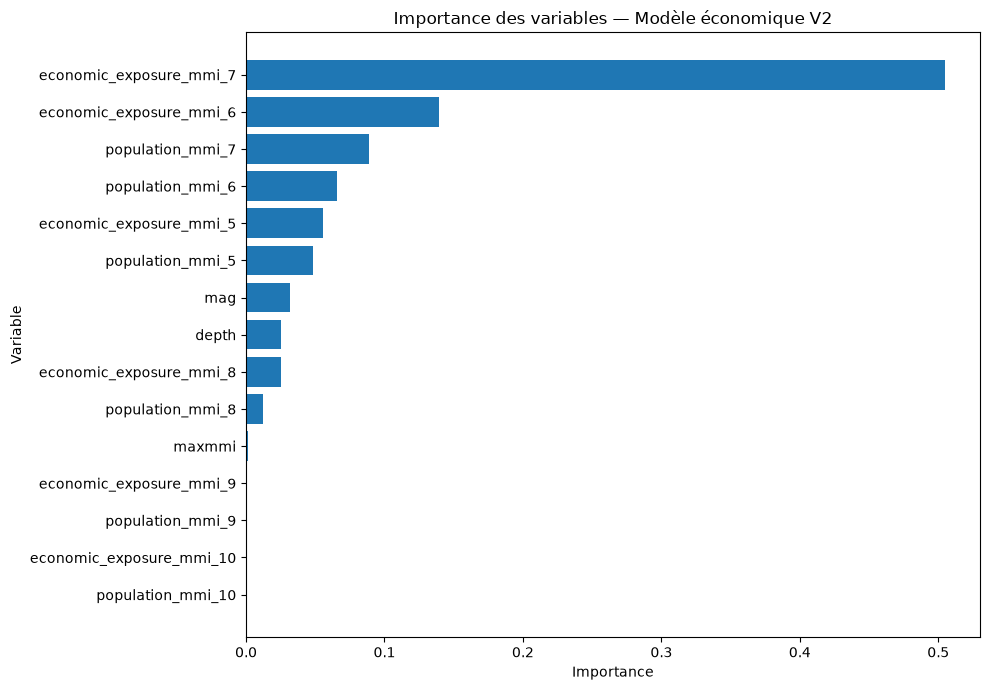

SVG sauvegardé avec succès.


In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance_v2["Variable"],
    feature_importance_v2["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Variable")
plt.title("Importance des variables — Modèle économique V2")

plt.tight_layout()

plt.savefig(
    "models/economic_loss_v2_feature_importance.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

print("SVG sauvegardé avec succès.")

## V3 — Estimation des pertes économiques pour un scénario futur

### Objectif

L'objectif de cette version est de simplifier l'utilisation du modèle.

L'utilisateur définit seulement :

- la localisation du séisme (latitude et longitude) ;
- la magnitude ;
- la profondeur.

Le système devra ensuite estimer les pertes économiques potentielles associées à ce scénario.

Cette approche ne cherche pas à prédire si un séisme va se produire. Elle répond plutôt à la question :

> **Si un séisme de cette magnitude et de cette profondeur se produisait à cet endroit, quelles pourraient être les pertes économiques ?**

Les variables complexes utilisées par le modèle V2, comme l'exposition de la population et l'exposition économique aux différents niveaux MMI, ne seront pas demandées directement à l'utilisateur.

In [69]:
import pandas as pd

df_v2 = pd.read_csv("data/economic_loss_model_v2_2025.csv")

print("Shape:", df_v2.shape)
print("\nColumns:")
for col in df_v2.columns:
    print("-", col)

Shape: (734, 19)

Columns:
- event_id
- mag
- depth
- tsunami
- maxmmi
- economic_loss
- population_mmi_5
- economic_exposure_mmi_5
- population_mmi_6
- economic_exposure_mmi_6
- population_mmi_7
- economic_exposure_mmi_7
- population_mmi_8
- economic_exposure_mmi_8
- population_mmi_9
- economic_exposure_mmi_9
- population_mmi_10
- economic_exposure_mmi_10
- has_economic_loss


### Ajout de la localisation

Le modèle de scénario doit connaître la localisation du séisme.

Les coordonnées latitude et longitude ne sont pas présentes dans le jeu de données V2. Elles sont récupérées à partir du jeu de données économique original en utilisant `event_id` comme identifiant commun.

In [70]:
df_original = pd.read_csv("data/economic_loss_model_2025.csv")

print("Shape original:", df_original.shape)
print("\nColonnes:")
print(df_original.columns.tolist())

print("\nLatitude manquante:", df_original["latitude"].isna().sum())
print("Longitude manquante:", df_original["longitude"].isna().sum())

Shape original: (734, 9)

Colonnes:
['event_id', 'mag', 'depth', 'sig', 'latitude', 'longitude', 'tsunami', 'place', 'economic_loss']

Latitude manquante: 0
Longitude manquante: 0


### Fusion avec les coordonnées géographiques

Les coordonnées géographiques sont ajoutées au jeu de données V2 à partir de l'identifiant unique `event_id`.

La latitude et la longitude permettront de représenter un scénario dans lequel l'utilisateur choisit directement la localisation d'un séisme sur la carte.

In [71]:
# Keep only the location information from the original dataset
location_data = df_original[
    ["event_id", "latitude", "longitude"]
].copy()

# Merge with V2
df_v3 = df_v2.merge(
    location_data,
    on="event_id",
    how="left"
)

print("Shape V3:", df_v3.shape)

print("\nMissing coordinates:")
print("Latitude :", df_v3["latitude"].isna().sum())
print("Longitude:", df_v3["longitude"].isna().sum())

print("\nScenario variables:")
print(
    df_v3[
        ["event_id", "mag", "depth", "latitude", "longitude", "economic_loss"]
    ].head()
)

Shape V3: (734, 21)

Missing coordinates:
Latitude : 0
Longitude: 0

Scenario variables:
     event_id  mag  depth  latitude  longitude  economic_loss
0  us7000q9fs  5.4   10.0   29.3062   129.3422              0
1  us7000q9f3  5.3   10.0   30.3495    69.7968          68378
2  us7000q9b5  6.6   10.0  -60.9793   -38.9672              0
3  us7000q99p  5.5  229.0  -19.8818  -176.0335              0
4  us7000q97d  6.0   99.7    5.2888   126.0425              0


### Modèle de scénario — Étape 1 : présence de pertes économiques

Avant d'estimer le montant des pertes, nous testons si les informations simples
d'un scénario — magnitude, profondeur et localisation — permettent d'identifier
les séismes susceptibles de produire des pertes économiques.

Variables utilisées :

- magnitude ;
- profondeur ;
- latitude ;
- longitude.

La cible est `has_economic_loss` :

- `0` : aucune perte économique estimée ;
- `1` : présence de pertes économiques.

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

scenario_features = [
    "mag",
    "depth",
    "latitude",
    "longitude"
]

X_scenario = df_v3[scenario_features]
y_scenario = df_v3["has_economic_loss"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_scenario,
    y_scenario,
    test_size=0.20,
    random_state=42,
    stratify=y_scenario
)

scenario_classifier = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

scenario_classifier.fit(X_train_s, y_train_s)

y_pred_s = scenario_classifier.predict(X_test_s)

print("Confusion matrix:")
print(confusion_matrix(y_test_s, y_pred_s))

print("\nClassification report:")
print(classification_report(y_test_s, y_pred_s, digits=4))

Confusion matrix:
[[112  13]
 [  9  13]]

Classification report:
              precision    recall  f1-score   support

           0     0.9256    0.8960    0.9106       125
           1     0.5000    0.5909    0.5417        22

    accuracy                         0.8503       147
   macro avg     0.7128    0.7435    0.7261       147
weighted avg     0.8619    0.8503    0.8554       147



### Modèle de scénario — Étape 2 : estimation du montant des pertes

Pour les séismes ayant produit une perte économique, nous testons maintenant
si les quatre variables simples du scénario peuvent également estimer le
montant des pertes :

- magnitude ;
- profondeur ;
- latitude ;
- longitude.

Le montant des pertes est transformé avec `log1p` afin de réduire l'effet
des valeurs économiques extrêmement élevées.

In [73]:
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_validate

# Keep only earthquakes with positive economic loss
positive_scenario = df_v3[
    df_v3["economic_loss"] > 0
].copy()

X_reg_scenario = positive_scenario[
    ["mag", "depth", "latitude", "longitude"]
]

y_reg_scenario = np.log1p(
    positive_scenario["economic_loss"]
)

scenario_regressor = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_validate(
    scenario_regressor,
    X_reg_scenario,
    y_reg_scenario,
    cv=cv,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    }
)

print("Positive-loss events:", len(positive_scenario))

print("\n5-fold cross-validation:")
print("MAE :", -scores["test_mae"].mean())
print("RMSE:", -scores["test_rmse"].mean())
print("R²  :", scores["test_r2"].mean())

Positive-loss events: 109

5-fold cross-validation:
MAE : 4.7881862392786285
RMSE: 5.754185221879012
R²  : 0.1274468580591289


### Estimation automatique de l'intensité maximale

Afin de conserver une interface simple, l'utilisateur ne saisira pas
manuellement l'intensité MMI.

Un modèle intermédiaire est testé pour estimer automatiquement la valeur
`maxmmi` à partir des informations simples du scénario :

- magnitude ;
- profondeur ;
- latitude ;
- longitude.

Cette étape constitue une approximation simplifiée d'un scénario de
secousse et ne remplace pas un calcul physique complet de ShakeMap.

In [74]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_validate

X_mmi = df_v3[
    ["mag", "depth", "latitude", "longitude"]
]

y_mmi = df_v3["maxmmi"]

mmi_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

cv_mmi = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

mmi_scores = cross_validate(
    mmi_model,
    X_mmi,
    y_mmi,
    cv=cv_mmi,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    }
)

print("5-fold cross-validation — Max MMI")
print("MAE :", -mmi_scores["test_mae"].mean())
print("RMSE:", -mmi_scores["test_rmse"].mean())
print("R²  :", mmi_scores["test_r2"].mean())

5-fold cross-validation — Max MMI
MAE : 0.7312528499984469
RMSE: 1.1761436793770335
R²  : 0.7011317110495637


### Estimation automatique de l'exposition de la population

Après l'estimation de l'intensité maximale, nous testons si le système peut
estimer automatiquement l'exposition de la population.

Un premier test est réalisé avec la population exposée au niveau MMI 7.

Les variables disponibles pour le scénario sont :

- magnitude ;
- profondeur ;
- latitude ;
- longitude ;
- intensité maximale MMI.

La variable `maxmmi` utilisée dans ce test est la valeur observée du jeu de
données. Si cette approche est retenue, la version finale devra utiliser
une valeur de MMI prédite sans fuite d'information.

In [75]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_validate
import numpy as np

X_pop7 = df_v3[
    ["mag", "depth", "latitude", "longitude", "maxmmi"]
]

# Population is highly skewed, so use log1p
y_pop7 = np.log1p(df_v3["population_mmi_7"])

pop7_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

cv_pop7 = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

pop7_scores = cross_validate(
    pop7_model,
    X_pop7,
    y_pop7,
    cv=cv_pop7,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    }
)

print("5-fold cross-validation — Population MMI 7")
print("MAE :", -pop7_scores["test_mae"].mean())
print("RMSE:", -pop7_scores["test_rmse"].mean())
print("R²  :", pop7_scores["test_r2"].mean())

5-fold cross-validation — Population MMI 7
MAE : 0.21308428218299236
RMSE: 0.7820050989360035
R²  : 0.8940513712427679


### Vérification de la distribution de la population exposée à MMI 7

Avant de retenir le modèle, il est nécessaire d'examiner la distribution
de la variable cible.

Une forte proportion de valeurs nulles pourrait rendre les métriques
globales artificiellement favorables.

In [76]:
pop7 = df_v3["population_mmi_7"]

print("Nombre total :", len(pop7))
print("Population MMI 7 = 0 :", (pop7 == 0).sum())
print("Population MMI 7 > 0 :", (pop7 > 0).sum())

print("\nPourcentage = 0 :",
      round((pop7 == 0).mean() * 100, 2), "%")

print("\nStatistiques pour les valeurs > 0:")
print(pop7[pop7 > 0].describe())

Nombre total : 734
Population MMI 7 = 0 : 680
Population MMI 7 > 0 : 54

Pourcentage = 0 : 92.64 %

Statistiques pour les valeurs > 0:
count    5.400000e+01
mean     3.063129e+05
std      1.238134e+06
min      1.000000e+00
25%      1.920250e+03
50%      1.477850e+04
75%      1.502482e+05
max      8.787774e+06
Name: population_mmi_7, dtype: float64


### Évaluation sur les séismes ayant une exposition réelle à MMI 7

La majorité des événements possède une population exposée à MMI 7 égale à zéro.

Afin d'éviter qu'un grand nombre de valeurs nulles donne une impression
trop optimiste des performances, le modèle est maintenant évalué uniquement
sur les événements pour lesquels la population exposée à MMI 7 est supérieure
à zéro.

In [77]:
# Keep only events with actual MMI 7 population exposure
df_pop7_positive = df_v3[
    df_v3["population_mmi_7"] > 0
].copy()

X_pop7_positive = df_pop7_positive[
    ["mag", "depth", "latitude", "longitude", "maxmmi"]
]

y_pop7_positive = np.log1p(
    df_pop7_positive["population_mmi_7"]
)

pop7_positive_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

cv_pop7_positive = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores_pop7_positive = cross_validate(
    pop7_positive_model,
    X_pop7_positive,
    y_pop7_positive,
    cv=cv_pop7_positive,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    }
)

print("Événements avec population MMI 7 > 0:",
      len(df_pop7_positive))

print("\n5-fold CV — Population MMI 7 > 0")
print("MAE :", -scores_pop7_positive["test_mae"].mean())
print("RMSE:", -scores_pop7_positive["test_rmse"].mean())
print("R²  :", scores_pop7_positive["test_r2"].mean())

Événements avec population MMI 7 > 0: 54

5-fold CV — Population MMI 7 > 0
MAE : 1.6784471017664182
RMSE: 2.025933805777452
R²  : 0.5190125536935071


### Test d'un modèle de scénario simplifié avec MMI

La prédiction directe des pertes à partir de la magnitude, de la profondeur
et de la localisation était insuffisante.

Nous ajoutons maintenant l'intensité maximale MMI comme variable intermédiaire.

Dans cette expérience, la valeur MMI observée est utilisée afin de mesurer
le potentiel de cette architecture. Si les résultats sont intéressants,
la version finale utilisera une MMI estimée automatiquement par le modèle
intermédiaire, sans demander cette information à l'utilisateur.

In [78]:
# Positive economic-loss events only
scenario_positive = df_v3[
    df_v3["economic_loss"] > 0
].copy()

X_scenario_mmi = scenario_positive[
    ["mag", "depth", "latitude", "longitude", "maxmmi"]
]

y_scenario_mmi = np.log1p(
    scenario_positive["economic_loss"]
)

scenario_mmi_regressor = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

cv_scenario_mmi = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scenario_mmi_scores = cross_validate(
    scenario_mmi_regressor,
    X_scenario_mmi,
    y_scenario_mmi,
    cv=cv_scenario_mmi,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    }
)

print("5-fold CV — Economic Loss with Max MMI")
print("MAE :", -scenario_mmi_scores["test_mae"].mean())
print("RMSE:", -scenario_mmi_scores["test_rmse"].mean())
print("R²  :", scenario_mmi_scores["test_r2"].mean())

5-fold CV — Economic Loss with Max MMI
MAE : 2.7857557429195596
RMSE: 3.467556825305657
R²  : 0.6771371855263073


### Validation du scénario avec une MMI prédite

Le test précédent utilisait la valeur MMI observée afin d'évaluer le potentiel
de l'architecture.

Pour obtenir une évaluation plus réaliste, nous générons maintenant une MMI
prédite pour chaque événement avec une validation croisée.

Ainsi, la MMI utilisée pour un événement est produite par un modèle qui
n'a pas été entraîné sur cet événement.

Cette étape permet de se rapprocher du fonctionnement réel de l'application,
où l'utilisateur fournira uniquement la localisation, la magnitude et la
profondeur.

In [79]:
from sklearn.model_selection import cross_val_predict

# Simple scenario inputs
X_mmi_scenario = df_v3[
    ["mag", "depth", "latitude", "longitude"]
]

# Generate out-of-fold MMI predictions
cv_mmi_oof = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

mmi_model_oof = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

df_v3["predicted_maxmmi"] = cross_val_predict(
    mmi_model_oof,
    X_mmi_scenario,
    df_v3["maxmmi"],
    cv=cv_mmi_oof
)

print(
    df_v3[
        ["maxmmi", "predicted_maxmmi"]
    ].head(10)
)

print(
    "\nCorrelation:",
    df_v3["maxmmi"].corr(df_v3["predicted_maxmmi"])
)

   maxmmi  predicted_maxmmi
0       3          3.666667
1       6          5.510000
2       0          0.033333
3       3          2.593333
4       5          4.300000
5       0          0.050000
6       4          5.616667
7       4          4.783333
8       4          3.973333
9       0          4.243333

Correlation: 0.8428546062869758


### Évaluation finale du modèle de scénario V3

La valeur MMI observée est remplacée par une MMI prédite hors échantillon.

Cette évaluation permet de tester une architecture proche de l'utilisation
finale de l'application, dans laquelle l'utilisateur fournit uniquement
la localisation, la magnitude et la profondeur du scénario.

In [80]:
# Keep positive-loss events
v3_positive = df_v3[
    df_v3["economic_loss"] > 0
].copy()

X_v3_final = v3_positive[
    [
        "mag",
        "depth",
        "latitude",
        "longitude",
        "predicted_maxmmi"
    ]
]

y_v3_final = np.log1p(
    v3_positive["economic_loss"]
)

v3_regressor = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

cv_v3 = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

v3_scores = cross_validate(
    v3_regressor,
    X_v3_final,
    y_v3_final,
    cv=cv_v3,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    }
)

print("V3 — Predicted MMI")
print("MAE :", -v3_scores["test_mae"].mean())
print("RMSE:", -v3_scores["test_rmse"].mean())
print("R²  :", v3_scores["test_r2"].mean())

V3 — Predicted MMI
MAE : 5.075282859013669
RMSE: 5.879342728358966
R²  : 0.09129765394897922


### Conclusion de l'expérimentation V3

L'objectif de V3 était de déterminer s'il était possible d'estimer les pertes
économiques d'un scénario hypothétique en demandant uniquement à l'utilisateur
la localisation, la magnitude et la profondeur.

Un premier modèle utilisant directement ces quatre variables pour estimer
les pertes économiques a obtenu un R² d'environ 0,13 en validation croisée,
ce qui indique une capacité prédictive insuffisante.

L'ajout de la MMI maximale observée améliorait fortement les résultats
(R² ≈ 0,68). Cependant, dans un scénario futur, cette intensité n'est pas
connue. Un modèle intermédiaire a donc été utilisé pour l'estimer à partir
de la magnitude, de la profondeur et de la localisation.

Lorsque la MMI prédite hors échantillon a été utilisée dans le modèle final,
le R² est tombé à environ 0,09. Les erreurs du modèle intermédiaire se
propagent donc à l'estimation des pertes économiques.

Cette expérimentation montre que la magnitude, la profondeur et la localisation
ne suffisent pas à elles seules pour obtenir une estimation fiable des pertes
économiques. L'exposition de la population et des actifs économiques aux
différents niveaux d'intensité apporte une information essentielle.

Pour cette raison, le modèle V2 basé sur les données d'exposition
PAGER/ShakeMap est conservé comme modèle principal d'estimation des pertes
économiques.